# AI-Driven Smart Retail Supply Chain Intelligence System

This project analyzes Walmart retail sales data as a supply chain intelligence case.  
The goal is to clean and prepare the data, explore sales and seasonal patterns, forecast future demand, predict demand risk, optimize inventory using ABC Analysis and clustering, and prepare business insights for Power BI dashboards.

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
# Load the datasets
sales = pd.read_csv("sales data-set.csv")
features = pd.read_csv("Features data set.csv")
stores = pd.read_csv("stores data-set.csv")

# Check the shape of each dataset
print("Sales dataset shape:", sales.shape)
print("Features dataset shape:", features.shape)
print("Stores dataset shape:", stores.shape)

Sales dataset shape: (421570, 5)
Features dataset shape: (8190, 12)
Stores dataset shape: (45, 3)


In [3]:
print("Sales dataset:")
display(sales.head())

print("Features dataset:")
display(features.head())

print("Stores dataset:")
display(stores.head())

Sales dataset:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


Features dataset:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


Stores dataset:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:
print("Sales dataset info:")
sales.info()

print("\nFeatures dataset info:")
features.info()

print("\nStores dataset info:")
stores.info()

Sales dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Features dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3 

In [5]:
print("Missing values in sales dataset:")
display(sales.isnull().sum())

print("Missing values in features dataset:")
display(features.isnull().sum())

print("Missing values in stores dataset:")
display(stores.isnull().sum())

Missing values in sales dataset:


,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


Missing values in features dataset:


,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


Missing values in stores dataset:


,0
Store,0
Type,0
Size,0


In [6]:
print("Duplicates in sales:", sales.duplicated().sum())
print("Duplicates in features:", features.duplicated().sum())
print("Duplicates in stores:", stores.duplicated().sum())

Duplicates in sales: 0
Duplicates in features: 0
Duplicates in stores: 0


In [7]:
# Convert Date columns to datetime format
sales["Date"] = pd.to_datetime(sales["Date"], format="%d/%m/%Y")
features["Date"] = pd.to_datetime(features["Date"], format="%d/%m/%Y")

print("Sales date range:", sales["Date"].min(), "to", sales["Date"].max())
print("Features date range:", features["Date"].min(), "to", features["Date"].max())

Sales date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Features date range: 2010-02-05 00:00:00 to 2013-07-26 00:00:00


In [8]:
# Merge sales with features using Store and Date
df = pd.merge(
    sales,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

# Merge with stores using Store
df = pd.merge(
    df,
    stores,
    on="Store",
    how="left"
)

print("Final merged dataset shape:", df.shape)
display(df.head())

Final merged dataset shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [9]:
# MarkDown columns mean promotional discount values.
# Missing MarkDown usually means no promotion, so we replace them with 0.
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    df[col] = df[col].fillna(0)

# CPI and Unemployment are economic indicators.
# We fill missing values with the median because it is more stable than mean.
df["CPI"] = df["CPI"].fillna(df["CPI"].median())
df["Unemployment"] = df["Unemployment"].fillna(df["Unemployment"].median())

print("Missing values after cleaning:")
display(df.isnull().sum())

Missing values after cleaning:


,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [10]:
# Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

# Create total markdown feature
df["Total_MarkDown"] = df[markdown_cols].sum(axis=1)

# Create sales per store size
df["Sales_per_Size"] = df["Weekly_Sales"] / df["Size"]

# Create holiday flag as integer
df["IsHoliday_Int"] = df["IsHoliday"].astype(int)

display(df.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Total_MarkDown,Sales_per_Size,IsHoliday_Int
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0,0.164719,0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0,0.304263,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0,0.274894,0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0,0.128233,0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0,0.144255,0


In [11]:
# Save cleaned dataset
df.to_csv("cleaned_retail_supply_chain_data.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final dataset shape:", df.shape)

Cleaned dataset saved successfully!
Final dataset shape: (421570, 23)


### Task 1 Interpretation

In this step, three datasets were loaded and merged into one final dataset.  
The sales dataset contains weekly sales by store and department. The features dataset adds external factors such as temperature, fuel price, CPI, unemployment, holidays, and markdown promotions. The stores dataset adds store type and size.

Missing values were mainly found in the MarkDown columns. These missing values were replaced with 0 because no markdown value usually means that no promotion was applied. Missing values in CPI and Unemployment were replaced with the median to avoid distortion from extreme values.

Additional time-based features such as Year, Month, Week, and Quarter were created to support trend analysis and forecasting. Total_MarkDown and Sales_per_Size were also created to help analyze promotion impact and store efficiency.

As a result, the dataset is now clean, merged, and ready for exploratory data analysis and machine learning.

## Task 2: Exploratory Data Analysis

In this section, we explore the main sales patterns in the retail supply chain dataset.  
We analyze weekly sales trends, store types, holiday impact, department performance, external economic factors, promotions, and outliers.

In [12]:
# Basic statistical summary
display(df.describe())

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Quarter,Total_MarkDown,Sales_per_Size,IsHoliday_Int
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739,2010.968591,6.449510,25.826762,2.482767,6684.041435,0.129608,0.070358
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,2010.000000,1.000000,1.000000,1.000000,0.000000,-0.037847,0.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,2010.000000,4.000000,14.000000,2.000000,0.000000,0.017344,0.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000,2011.000000,6.000000,26.000000,2.000000,0.000000,0.058789,0.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000,2012.000000,9.000000,38.000000,3.000000,8075.260000,0.160853,0.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012.000000,12.000000,52.000000,4.000000,160510.610000,6.267013,1.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328,0.796876,3.243217,14.151887,1.071341,14750.941552,0.204135,0.255750


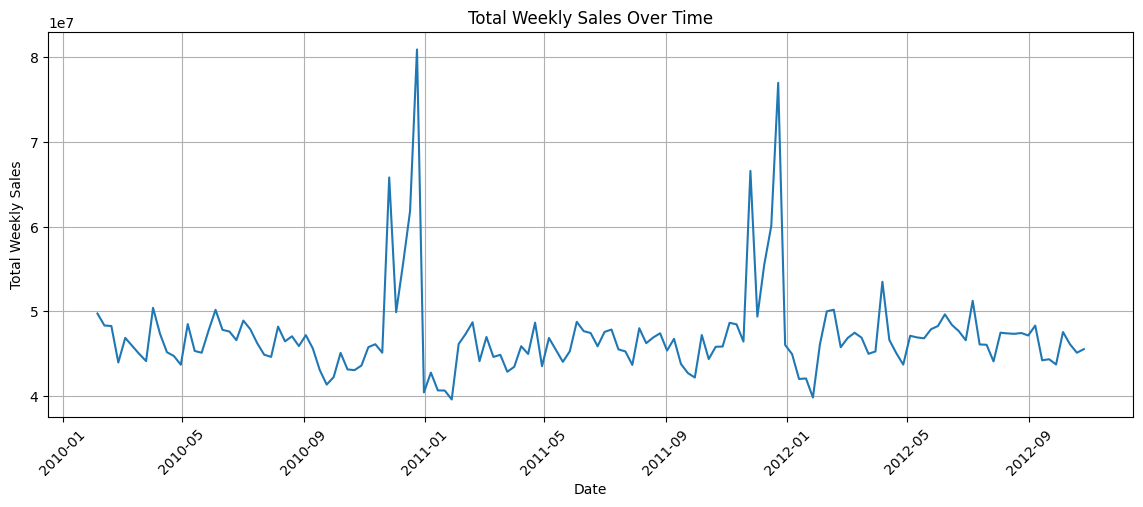

In [13]:
# Weekly sales trend over time
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

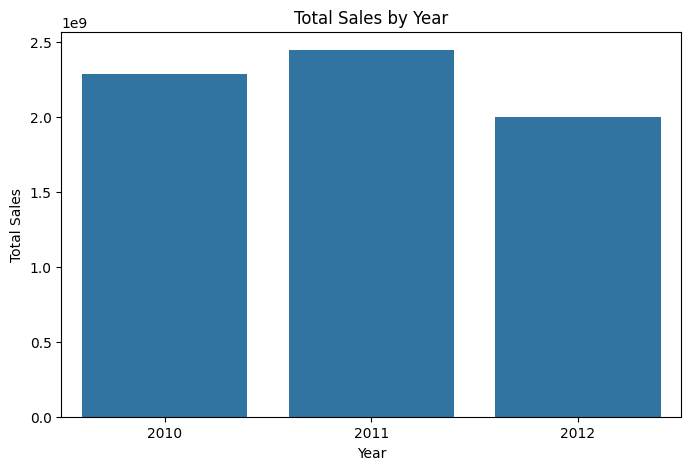

,Year,Weekly_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


In [14]:
# Sales by year
sales_by_year = df.groupby("Year")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_year, x="Year", y="Weekly_Sales")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

display(sales_by_year)

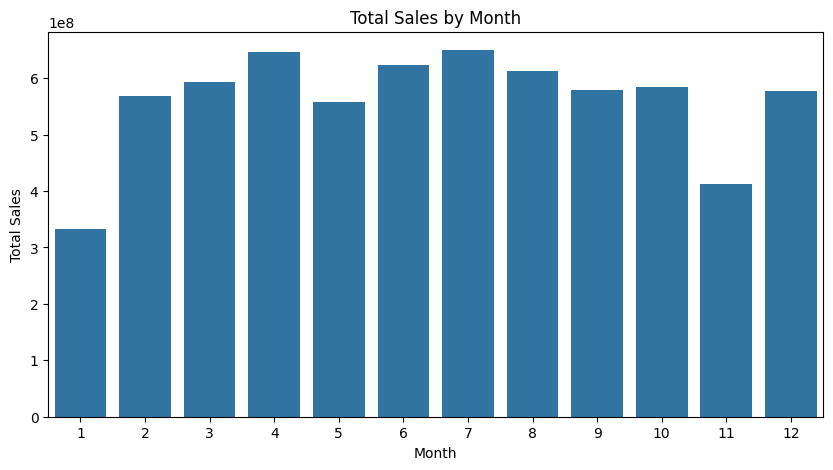

,Month,Weekly_Sales
0,1,3.325984e+08
1,2,5.687279e+08
2,3,5.927859e+08
3,4,6.468598e+08
4,5,5.571256e+08
5,6,6.226299e+08
6,7,6.500010e+08
7,8,6.130902e+08
8,9,5.787612e+08
9,10,5.847848e+08


In [15]:
# Sales by month
sales_by_month = df.groupby("Month")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_month, x="Month", y="Weekly_Sales")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

display(sales_by_month)

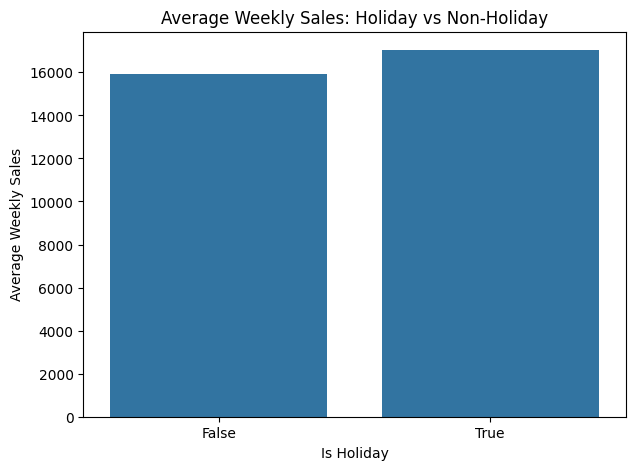

,IsHoliday,Weekly_Sales
0,False,15901.445069
1,True,17035.823187


In [16]:
# Average sales during holidays and non-holidays
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=holiday_sales, x="IsHoliday", y="Weekly_Sales")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

display(holiday_sales)

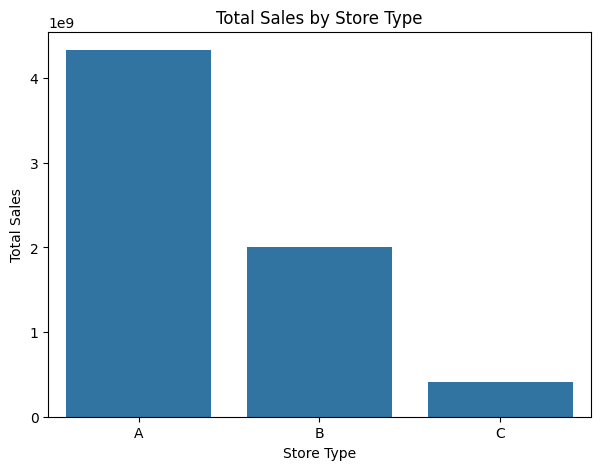

,Type,Weekly_Sales
0,A,4.331015e+09
1,B,2.000701e+09
2,C,4.055035e+08


In [17]:
# Sales by store type
store_type_sales = df.groupby("Type")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=store_type_sales, x="Type", y="Weekly_Sales")
plt.title("Total Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Sales")
plt.show()

display(store_type_sales)

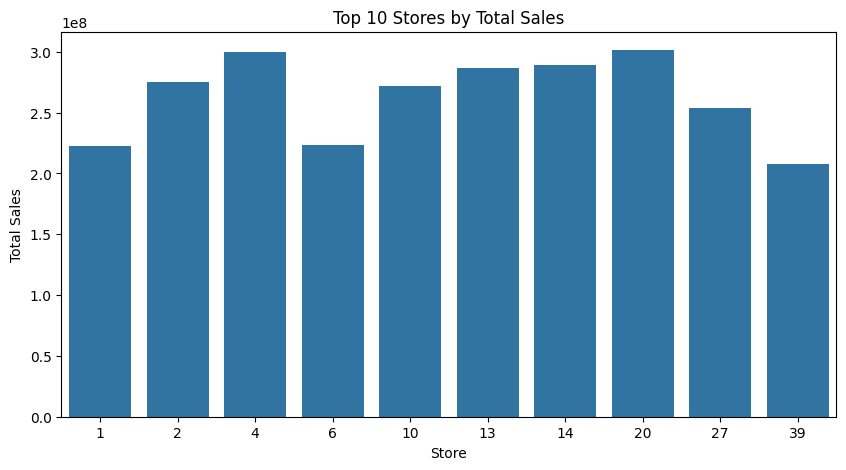

,Store,Weekly_Sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08
5,10,2.716177e+08
6,27,2.538559e+08
7,6,2.237561e+08
8,1,2.224028e+08
9,39,2.074455e+08


In [18]:
# Top 10 stores by total sales
top_stores = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_stores, x="Store", y="Weekly_Sales")
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

display(top_stores)

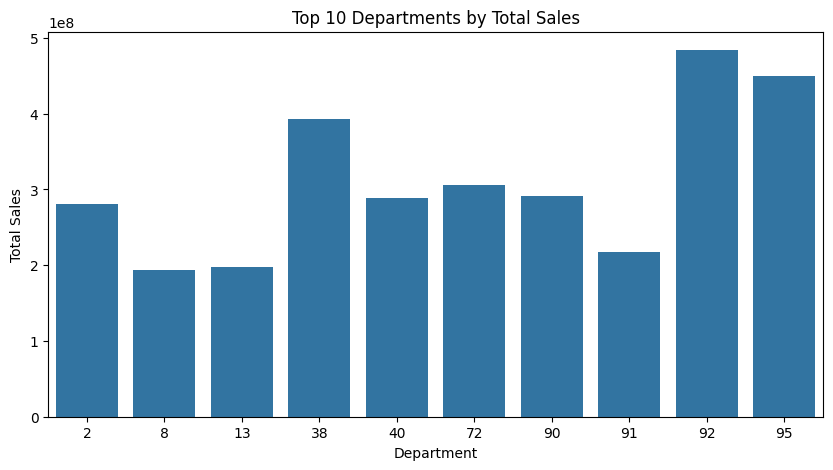

,Dept,Weekly_Sales
0,92,4.839433e+08
1,95,4.493202e+08
2,38,3.931181e+08
3,72,3.057252e+08
4,90,2.910685e+08
5,40,2.889360e+08
6,2,2.806112e+08
7,91,2.167817e+08
8,13,1.973216e+08
9,8,1.942808e+08


In [19]:
# Top 10 departments by total sales
top_departments = df.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_departments, x="Dept", y="Weekly_Sales")
plt.title("Top 10 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.show()

display(top_departments)

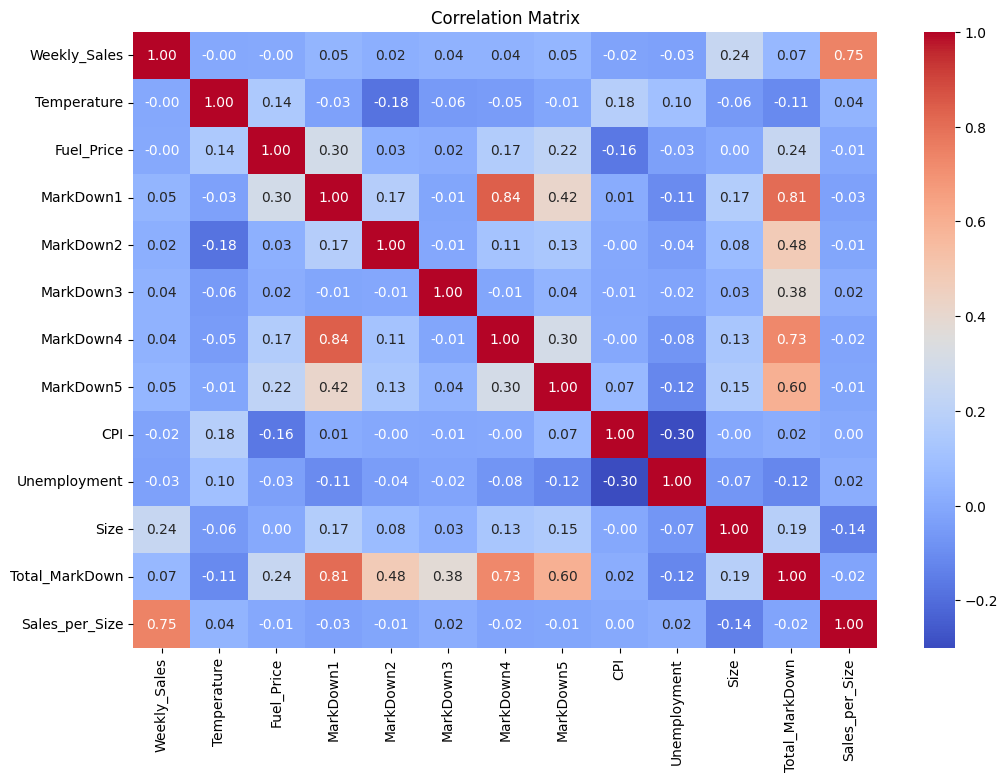

In [20]:
# Correlation matrix for numerical columns
numeric_cols = [
    "Weekly_Sales", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Size", "Total_MarkDown", "Sales_per_Size"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

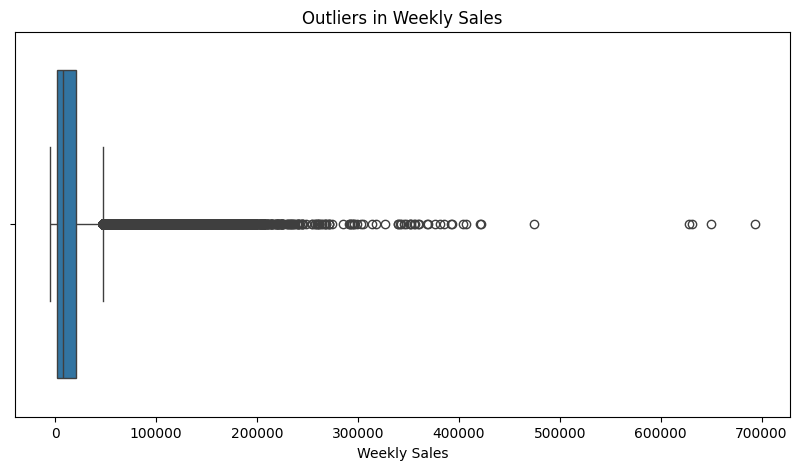

In [21]:
# Boxplot for Weekly Sales
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Outliers in Weekly Sales")
plt.xlabel("Weekly Sales")
plt.show()

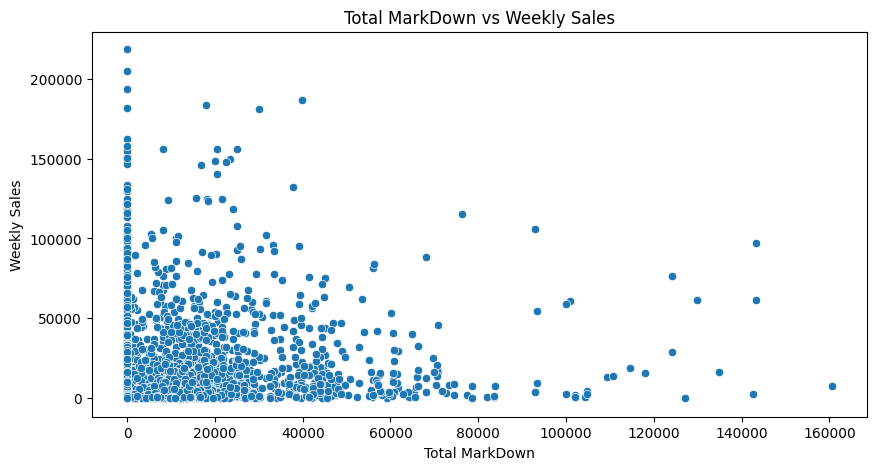

In [22]:
# Relationship between total markdown and weekly sales
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x="Total_MarkDown", y="Weekly_Sales")
plt.title("Total MarkDown vs Weekly Sales")
plt.xlabel("Total MarkDown")
plt.ylabel("Weekly Sales")
plt.show()

In [23]:
# Export summary tables for Power BI

weekly_sales.to_csv("powerbi_weekly_sales_trend.csv", index=False)
sales_by_year.to_csv("powerbi_sales_by_year.csv", index=False)
sales_by_month.to_csv("powerbi_sales_by_month.csv", index=False)
holiday_sales.to_csv("powerbi_holiday_sales.csv", index=False)
store_type_sales.to_csv("powerbi_store_type_sales.csv", index=False)В
top_stores.to_csv("powerbi_top_stores.csv", index=False)
top_departments.to_csv("powerbi_top_departments.csv", index=False)

print("EDA summary files saved successfully!")

EDA summary files saved successfully!


### EDA Interpretation

The total weekly sales trend shows clear seasonal peaks. The strongest increases appear around the end of the year, which is likely connected with holiday shopping periods. This means that the company should prepare more inventory before high-demand weeks.

Sales by year show that 2011 had the highest total sales. Sales in 2012 are lower mainly because the dataset ends in October 2012, so it does not include the full year.

Sales by month show that sales are not equally distributed across the year. Some months, especially April, July, and December, show stronger sales activity. This confirms the presence of seasonality in retail demand.

Holiday weeks have higher average weekly sales than non-holiday weeks. This means holidays are important demand drivers and should be included in forecasting and inventory planning.

Store Type A generates the highest total sales, followed by Type B and Type C. This shows that Type A stores are the most important for revenue and should receive the strongest supply chain support.

The top stores by sales are Store 20, Store 4, Store 14, Store 13, and Store 2. These stores are key business locations and should be prioritized in demand forecasting and stock planning.

The top departments are 92, 95, 38, 72, and 90. These departments generate the largest part of total sales, so they are important for ABC Analysis and inventory optimization.

The correlation matrix shows that store size has a positive relationship with weekly sales. Sales per size is also strongly related to weekly sales. Markdown variables have weaker direct correlation with sales, which means promotions may influence sales but not in a simple linear way.

The boxplot shows many high-value outliers in weekly sales. These values should not be removed automatically because they may represent real business events such as holidays, promotions, or high-performing departments.

The markdown scatter plot shows that higher markdowns do not always lead to higher sales. This means promotions should be analyzed carefully because discount spending does not guarantee demand growth.

## Task 3: Demand Forecasting

In this task, we forecast retail demand using several forecasting methods required in the project instructions.

The target variable is Weekly_Sales, because it represents demand in the retail supply chain.  
To make the analysis stronger, we use both machine learning models and time-series forecasting models:

- Linear Regression
- Random Forest Regressor
- ARIMA
- Prophet

Linear Regression and Random Forest are used to predict weekly sales based on store, department, economic, promotional, holiday, and time-based features.  
ARIMA and Prophet are used for time-series forecasting based on historical monthly sales trends.

This creates a complete demand forecasting pipeline for supply chain planning.

In [28]:
# -------------------------------
# DEMAND FORECASTING WITH ML MODELS
# Linear Regression + Random Forest
# -------------------------------

forecast_df = df.copy()

# Encode categorical variable: Store Type
le = LabelEncoder()
forecast_df["Type_Encoded"] = le.fit_transform(forecast_df["Type"])

# Select features for demand forecasting
features_forecast = [
    "Store", "Dept", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Size",
    "Year", "Month", "Week", "Quarter",
    "IsHoliday_Int", "Total_MarkDown", "Type_Encoded"
]

X = forecast_df[features_forecast]
y = forecast_df["Weekly_Sales"]

# Split data into train and test parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# -------------------------------
# Model 1: Linear Regression
# -------------------------------

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

# -------------------------------
# Model 2: Random Forest Regressor
# -------------------------------

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Regressor Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

# -------------------------------
# Model comparison table
# -------------------------------

ml_forecast_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

display(ml_forecast_results)

Training data shape: (337256, 19)
Testing data shape: (84314, 19)

Linear Regression Results
MAE: 14551.750602278806
RMSE: 21790.260986340996
R2 Score: 0.08946905899297364

Random Forest Regressor Results
MAE: 1456.408364871789
RMSE: 3721.6521984915175
R2 Score: 0.9734391840088724


,Model,MAE,RMSE,R2 Score
0,Linear Regression,14551.750602,21790.260986,0.089469
1,Random Forest Regressor,1456.408365,3721.652198,0.973439


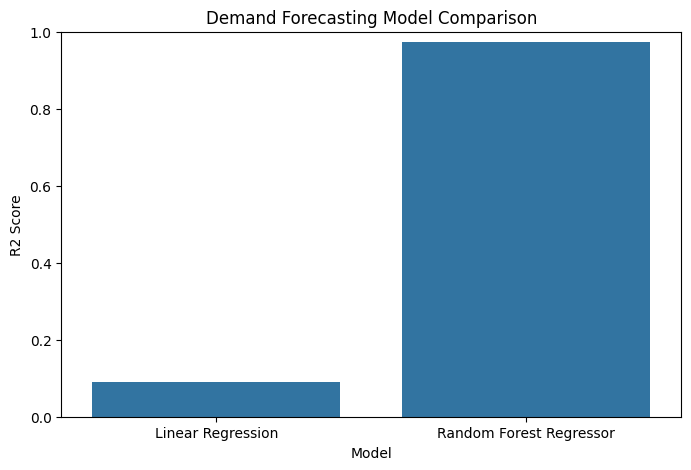

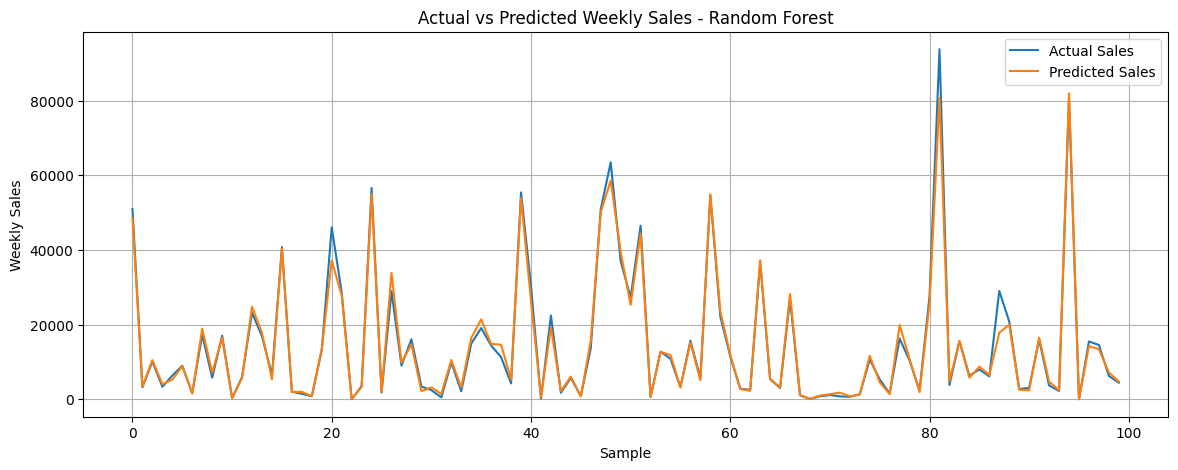

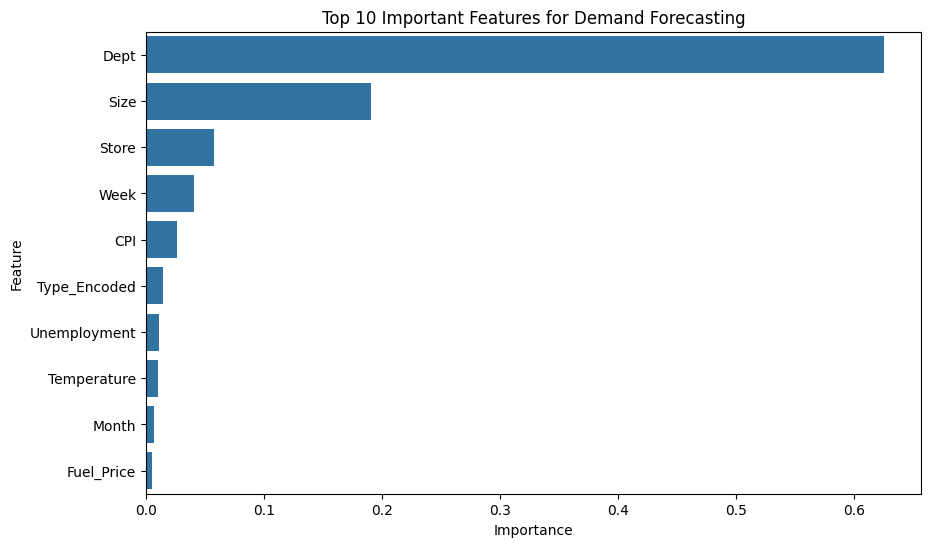

,Feature,Importance
1,Dept,0.625626
11,Size,0.190647
0,Store,0.057487
14,Week,0.040461
9,CPI,0.026429
18,Type_Encoded,0.014544
10,Unemployment,0.011014
2,Temperature,0.010184
13,Month,0.007162
3,Fuel_Price,0.004981


In [29]:
# -------------------------------
# VISUALIZATION OF ML RESULTS
# -------------------------------

# R2 Score comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=ml_forecast_results, x="Model", y="R2 Score")
plt.title("Demand Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
plt.show()

# Actual vs predicted sales for Random Forest
prediction_sample = pd.DataFrame({
    "Actual Sales": y_test.values[:100],
    "Predicted Sales": rf_pred[:100]
})

plt.figure(figsize=(14, 5))
plt.plot(prediction_sample["Actual Sales"].values, label="Actual Sales")
plt.plot(prediction_sample["Predicted Sales"].values, label="Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales - Random Forest")
plt.xlabel("Sample")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": features_forecast,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features for Demand Forecasting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(feature_importance.head(10))

,Date,Monthly_Sales
0,2010-02-28,1.903330e+08
1,2010-03-31,1.819198e+08
2,2010-04-30,2.314124e+08
3,2010-05-31,1.867109e+08
4,2010-06-30,1.922462e+08


,Date,Monthly_Sales
28,2012-06-30,2.406103e+08
29,2012-07-31,1.875095e+08
30,2012-08-31,2.368508e+08
31,2012-09-30,1.806455e+08
32,2012-10-31,1.843617e+08


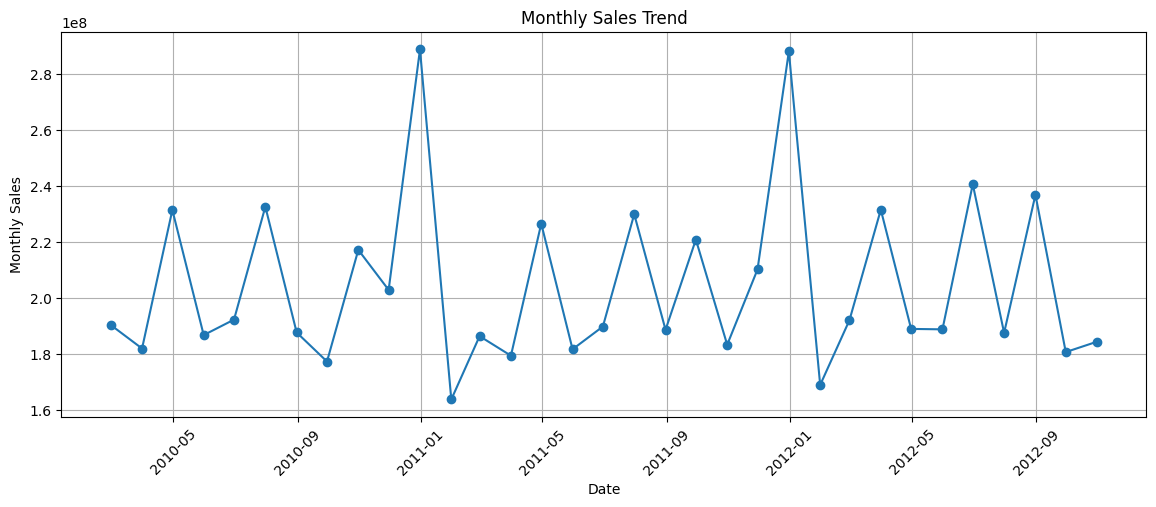

In [30]:
# -------------------------------
# MONTHLY SALES DATA FOR TIME-SERIES FORECASTING
# ARIMA + Prophet
# -------------------------------

# Aggregate weekly sales into monthly sales
monthly_sales = df.groupby(pd.Grouper(key="Date", freq="M"))["Weekly_Sales"].sum().reset_index()

# Rename columns for easier work
monthly_sales.columns = ["Date", "Monthly_Sales"]

display(monthly_sales.head())
display(monthly_sales.tail())

# Visualize monthly sales trend
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["Date"], monthly_sales["Monthly_Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


,Date,ARIMA_Forecast
0,2012-11-30,2.004026e+08
1,2012-12-31,2.001428e+08
2,2013-01-31,2.001470e+08
3,2013-02-28,2.001469e+08
4,2013-03-31,2.001469e+08
5,2013-04-30,2.001469e+08


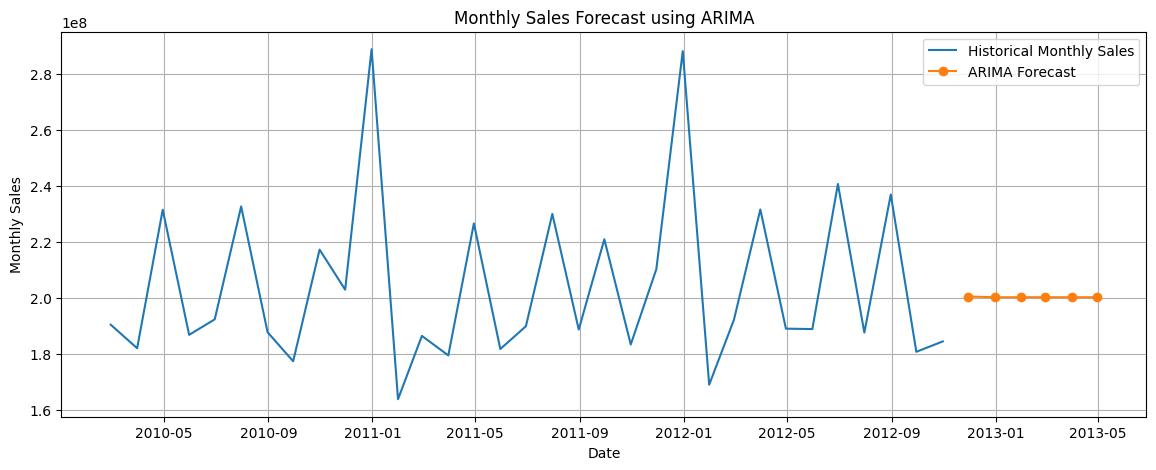

In [31]:
# -------------------------------
# ARIMA FORECASTING
# -------------------------------

from statsmodels.tsa.arima.model import ARIMA

# Prepare monthly sales as time series
monthly_ts = monthly_sales.set_index("Date")["Monthly_Sales"]

# Train ARIMA model
# Order (1,1,1) is used as a simple ARIMA structure for trend-based forecasting
arima_model = ARIMA(monthly_ts, order=(1, 1, 1))
arima_result = arima_model.fit()

# Forecast next 6 months
arima_forecast = arima_result.forecast(steps=6)

# Create future dates
future_dates_arima = pd.date_range(
    start=monthly_sales["Date"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="M"
)

arima_forecast_df = pd.DataFrame({
    "Date": future_dates_arima,
    "ARIMA_Forecast": arima_forecast.values
})

display(arima_forecast_df)

# Visualize ARIMA forecast
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["Date"], monthly_sales["Monthly_Sales"], label="Historical Monthly Sales")
plt.plot(arima_forecast_df["Date"], arima_forecast_df["ARIMA_Forecast"], label="ARIMA Forecast", marker="o")
plt.title("Monthly Sales Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper
33,2012-11-30,2.200299e+08,2.089634e+08,2.308854e+08
34,2012-12-31,3.075860e+08,2.960993e+08,3.178908e+08
35,2013-01-31,1.489880e+08,1.383893e+08,1.600034e+08
36,2013-02-28,1.939337e+08,1.835449e+08,2.045132e+08
37,2013-03-31,2.124165e+08,2.016684e+08,2.234361e+08
38,2013-04-30,2.088048e+08,1.984196e+08,2.205194e+08


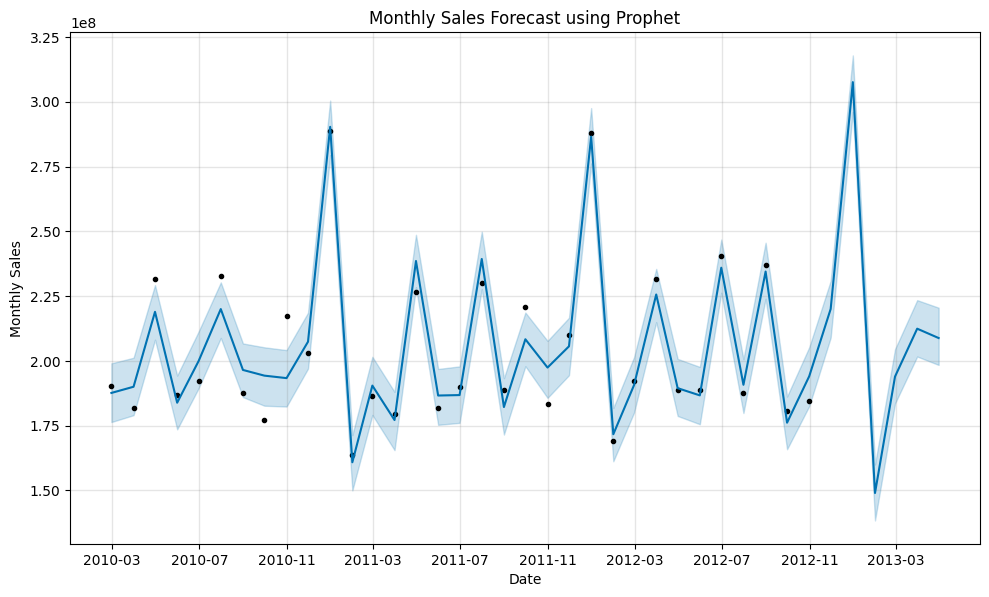

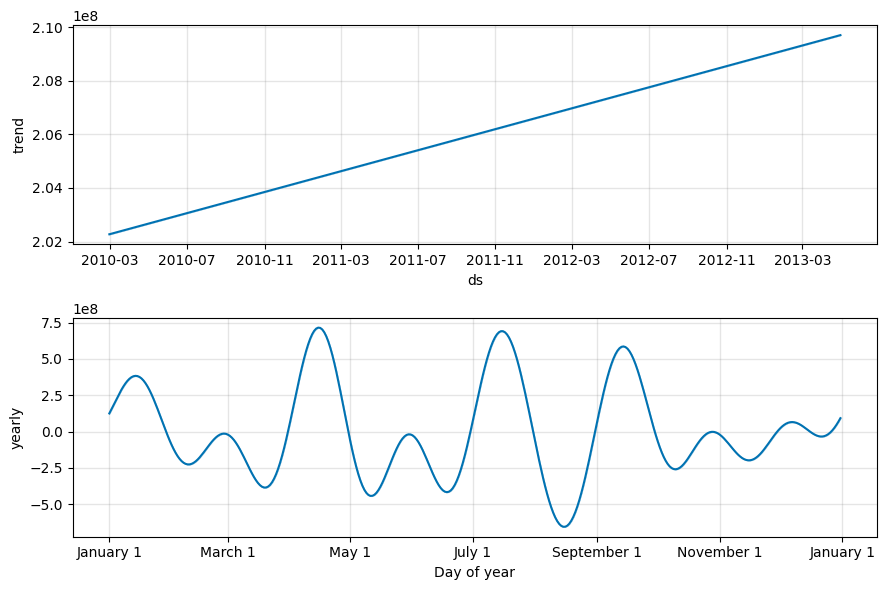

In [32]:
# -------------------------------
# PROPHET FORECASTING
# -------------------------------

# If Prophet is not installed, run this line once:
# !pip install prophet

try:
    from prophet import Prophet
except:
    !pip install prophet
    from prophet import Prophet

# Prophet requires columns named ds and y
prophet_df = monthly_sales.rename(columns={
    "Date": "ds",
    "Monthly_Sales": "y"
})

# Train Prophet model
prophet_model = Prophet()
prophet_model.fit(prophet_df)

# Forecast next 6 months
future = prophet_model.make_future_dataframe(periods=6, freq="M")
prophet_forecast = prophet_model.predict(future)

# Keep only future forecast rows
prophet_future_forecast = prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

display(prophet_future_forecast)

# Visualize Prophet forecast
fig1 = prophet_model.plot(prophet_forecast)
plt.title("Monthly Sales Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.show()

# Prophet components: trend and seasonality
fig2 = prophet_model.plot_components(prophet_forecast)
plt.show()

,Date,Forecasted_Monthly_Sales,Lower_Forecast,Upper_Forecast,Inventory_Need_Level
33,2012-11-30,2.200299e+08,2.089634e+08,2.308854e+08,Normal inventory need
34,2012-12-31,3.075860e+08,2.960993e+08,3.178908e+08,High inventory need
35,2013-01-31,1.489880e+08,1.383893e+08,1.600034e+08,Low inventory need
36,2013-02-28,1.939337e+08,1.835449e+08,2.045132e+08,Low inventory need
37,2013-03-31,2.124165e+08,2.016684e+08,2.234361e+08,Normal inventory need
38,2013-04-30,2.088048e+08,1.984196e+08,2.205194e+08,Normal inventory need


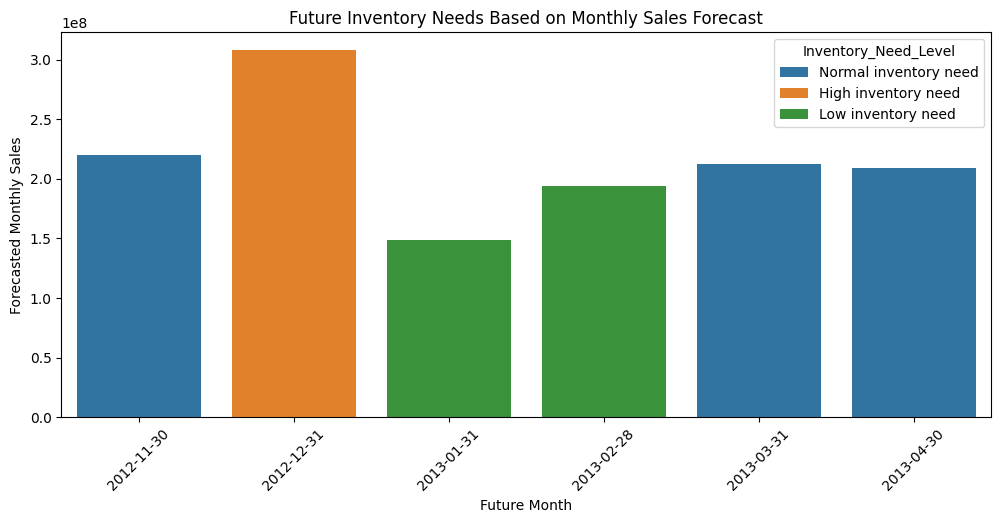

In [33]:
# -------------------------------
# FUTURE INVENTORY NEEDS
# Based on Prophet monthly forecast
# -------------------------------

# We use Prophet forecast because it provides trend and uncertainty interval
inventory_forecast = prophet_future_forecast.copy()

inventory_forecast = inventory_forecast.rename(columns={
    "ds": "Date",
    "yhat": "Forecasted_Monthly_Sales",
    "yhat_lower": "Lower_Forecast",
    "yhat_upper": "Upper_Forecast"
})

# Create simple inventory need category
avg_forecast = inventory_forecast["Forecasted_Monthly_Sales"].mean()

def inventory_need_level(value):
    if value > avg_forecast * 1.05:
        return "High inventory need"
    elif value < avg_forecast * 0.95:
        return "Low inventory need"
    else:
        return "Normal inventory need"

inventory_forecast["Inventory_Need_Level"] = inventory_forecast["Forecasted_Monthly_Sales"].apply(inventory_need_level)

display(inventory_forecast)

# Visualize future inventory needs
plt.figure(figsize=(12, 5))
sns.barplot(data=inventory_forecast, x="Date", y="Forecasted_Monthly_Sales", hue="Inventory_Need_Level")
plt.title("Future Inventory Needs Based on Monthly Sales Forecast")
plt.xlabel("Future Month")
plt.ylabel("Forecasted Monthly Sales")
plt.xticks(rotation=45)
plt.show()

In [34]:
# -------------------------------
# SAVE FORECASTING OUTPUTS FOR POWER BI
# -------------------------------

# ML prediction output
forecast_output = X_test.copy()
forecast_output["Actual_Weekly_Sales"] = y_test.values
forecast_output["Linear_Regression_Prediction"] = lr_pred
forecast_output["Random_Forest_Prediction"] = rf_pred
forecast_output["RF_Prediction_Error"] = forecast_output["Actual_Weekly_Sales"] - forecast_output["Random_Forest_Prediction"]

# Save files
forecast_output.to_csv("powerbi_ml_demand_forecast_predictions.csv", index=False)
ml_forecast_results.to_csv("powerbi_ml_forecasting_model_results.csv", index=False)
feature_importance.to_csv("powerbi_forecasting_feature_importance.csv", index=False)

monthly_sales.to_csv("powerbi_monthly_sales_history.csv", index=False)
arima_forecast_df.to_csv("powerbi_arima_monthly_forecast.csv", index=False)
prophet_future_forecast.to_csv("powerbi_prophet_monthly_forecast.csv", index=False)
inventory_forecast.to_csv("powerbi_future_inventory_needs.csv", index=False)

print("All forecasting files for Power BI saved successfully!")

All forecasting files for Power BI saved successfully!


### Task 3 Interpretation

The demand forecasting task was completed using four methods: Linear Regression, Random Forest Regressor, ARIMA, and Prophet. This creates a stronger forecasting pipeline because the project uses both machine learning models and time-series forecasting models.

Linear Regression was used as a baseline model. Its performance was weak, with an R2 Score of about 0.089. This means that a simple linear model cannot explain weekly sales well. Retail demand is more complex and depends on non-linear combinations of store, department, season, promotion, holiday, and economic factors.

Random Forest Regressor performed much better, with an R2 Score of about 0.973. This means the model explains most of the variation in weekly sales and gives much more accurate demand predictions. The Actual vs Predicted graph also shows that the predicted sales line follows the actual sales line closely. Therefore, Random Forest is the best model for weekly sales prediction in this project.

The feature importance chart shows that Department is the most important factor for demand forecasting. Store size, store number, week, and CPI also influence sales. This means that demand planning should not be done only at the total company level. The company should forecast demand separately by department, store, and time period.

ARIMA was used for monthly sales forecasting based on historical sales trends. The ARIMA forecast produced a stable forecast of around 200 million monthly sales for the next months. This model is useful as a simple time-series benchmark, but it does not capture strong seasonal peaks very well.

Prophet was also used for monthly forecasting. It gives forecasted monthly sales together with lower and upper forecast ranges. This is useful for business planning because it shows not only one expected value, but also possible uncertainty around future demand.

Based on the Prophet forecast, future inventory need levels were created. December 2012 shows high inventory need, while January and February 2013 show lower inventory need. This means the company should prepare more inventory before high-demand months and reduce overstock risk during lower-demand periods.

Overall, the forecasting results show that Random Forest is the strongest model for weekly demand prediction, while Prophet is useful for monthly business forecasting and inventory planning.

## Task 4: Delivery Delay Prediction Module

The original Walmart retail dataset does not contain direct logistics fields such as shipping mode, route distance, warehouse, traffic, region, or order priority.  
However, the final exam task requires a delivery delay prediction module.

To solve this, we create a proxy logistics layer based on available retail and supply chain variables.  
Store numbers are grouped into regions and warehouses, store type is used as a proxy for shipping mode, sales intensity is used to define order priority, and traffic pressure is estimated from fuel price, holiday periods, and weekly demand.

The delivery delay probability is created using the logistic formula:

P(Y=1) = 1 / (1 + e^−(β₀ + β₁x))

Then, three classification models are trained:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

The goal is to predict whether delivery is likely to be delayed and identify high-risk routes.

In [35]:
# -------------------------------
# TASK 4: DELIVERY DELAY PREDICTION
# Creating proxy logistics features
# -------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

delivery_df = df.copy()

# Sort data for lag-based features
delivery_df = delivery_df.sort_values(["Store", "Dept", "Date"])

# Previous week sales by Store and Department
delivery_df["Previous_Weekly_Sales"] = delivery_df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
delivery_df["Previous_Weekly_Sales"] = delivery_df["Previous_Weekly_Sales"].fillna(delivery_df["Weekly_Sales"].median())

# Demand change shows sudden sales pressure
delivery_df["Demand_Change"] = delivery_df["Weekly_Sales"] - delivery_df["Previous_Weekly_Sales"]

# Sales pressure: current sales compared with average sales
avg_sales = delivery_df["Weekly_Sales"].mean()
delivery_df["Sales_Pressure"] = delivery_df["Weekly_Sales"] / avg_sales

# -------------------------------
# Proxy Region based on Store number
# -------------------------------

def assign_region(store):
    if store <= 11:
        return "East"
    elif store <= 23:
        return "Central"
    elif store <= 35:
        return "South"
    else:
        return "West"

delivery_df["Region"] = delivery_df["Store"].apply(assign_region)

# -------------------------------
# Proxy Warehouse based on Region
# -------------------------------

warehouse_map = {
    "East": "Warehouse_E",
    "Central": "Warehouse_C",
    "South": "Warehouse_S",
    "West": "Warehouse_W"
}

delivery_df["Warehouse"] = delivery_df["Region"].map(warehouse_map)

# -------------------------------
# Proxy Shipping Mode based on Store Type
# -------------------------------

shipping_mode_map = {
    "A": "Standard Class",
    "B": "Second Class",
    "C": "Same Day"
}

delivery_df["Shipping_Mode"] = delivery_df["Type"].map(shipping_mode_map)

# -------------------------------
# Proxy Distance based on Store number
# This creates stable route distance values for each store
# -------------------------------

delivery_df["Distance_km"] = 50 + (delivery_df["Store"] * 23) + (delivery_df["Dept"] % 10) * 5

# Store Type C gets extra distance pressure because these are smaller / less central stores
delivery_df.loc[delivery_df["Type"] == "C", "Distance_km"] += 150

# -------------------------------
# Proxy Order Priority based on sales level
# -------------------------------

delivery_df["Order_Priority"] = pd.qcut(
    delivery_df["Weekly_Sales"],
    q=4,
    labels=["Low", "Medium", "High", "Critical"]
)

# -------------------------------
# Proxy Traffic Index
# Higher fuel price, holiday weeks, and demand pressure increase logistics pressure
# -------------------------------

fuel_scaled = (delivery_df["Fuel_Price"] - delivery_df["Fuel_Price"].min()) / (delivery_df["Fuel_Price"].max() - delivery_df["Fuel_Price"].min())
sales_pressure_scaled = (delivery_df["Sales_Pressure"] - delivery_df["Sales_Pressure"].min()) / (delivery_df["Sales_Pressure"].max() - delivery_df["Sales_Pressure"].min())

delivery_df["Traffic_Index"] = (
    0.4 * fuel_scaled +
    0.4 * sales_pressure_scaled +
    0.2 * delivery_df["IsHoliday_Int"]
)

display(delivery_df[[
    "Store", "Dept", "Date", "Weekly_Sales",
    "Region", "Warehouse", "Shipping_Mode",
    "Distance_km", "Order_Priority", "Traffic_Index"
]].head())

,Store,Dept,Date,Weekly_Sales,Region,Warehouse,Shipping_Mode,Distance_km,Order_Priority,Traffic_Index
0,1,1,2010-02-05,24924.50,East,Warehouse_E,Standard Class,78,Critical,0.037180
1,1,1,2010-02-12,46039.49,East,Warehouse_E,Standard Class,78,Critical,0.244469
2,1,1,2010-02-19,41595.55,East,Warehouse_E,Standard Class,78,Critical,0.035109
3,1,1,2010-02-26,19403.54,East,Warehouse_E,Standard Class,78,High,0.031812
4,1,1,2010-03-05,21827.90,East,Warehouse_E,Standard Class,78,Critical,0.046027


In [36]:
# -------------------------------
# Creating Delivery Delay Probability using logistic formula
# P(Y=1) = 1 / (1 + e^-(z))
# -------------------------------

# Binary indicators for delay risk factors
delivery_df["Long_Distance"] = (delivery_df["Distance_km"] > delivery_df["Distance_km"].median()).astype(int)
delivery_df["High_Traffic"] = (delivery_df["Traffic_Index"] > delivery_df["Traffic_Index"].quantile(0.75)).astype(int)
delivery_df["High_Priority"] = delivery_df["Order_Priority"].isin(["High", "Critical"]).astype(int)
delivery_df["Holiday_Week"] = delivery_df["IsHoliday_Int"]
delivery_df["High_Fuel_Price"] = (delivery_df["Fuel_Price"] > delivery_df["Fuel_Price"].median()).astype(int)

# Logistic formula components
z = (
    -2.5
    + 0.9 * delivery_df["Long_Distance"]
    + 1.3 * delivery_df["High_Traffic"]
    + 0.8 * delivery_df["High_Priority"]
    + 0.7 * delivery_df["Holiday_Week"]
    + 0.6 * delivery_df["High_Fuel_Price"]
)

# Delay probability from logistic formula
delivery_df["Delay_Probability_Formula"] = 1 / (1 + np.exp(-z))

# Create target variable
delivery_df["Delivery_Delay"] = (delivery_df["Delay_Probability_Formula"] >= 0.5).astype(int)

print("Delivery delay distribution:")
display(delivery_df["Delivery_Delay"].value_counts())

print("Delivery delay percentage:")
display(delivery_df["Delivery_Delay"].value_counts(normalize=True) * 100)

display(delivery_df[[
    "Long_Distance", "High_Traffic", "High_Priority",
    "Holiday_Week", "High_Fuel_Price",
    "Delay_Probability_Formula", "Delivery_Delay"
]].head())

Delivery delay distribution:


,count
Delivery_Delay,
0,332348
1,89222


Delivery delay percentage:


,proportion
Delivery_Delay,
0,78.835781
1,21.164219


,Long_Distance,High_Traffic,High_Priority,Holiday_Week,High_Fuel_Price,Delay_Probability_Formula,Delivery_Delay
0,0,0,1,0,0,0.154465,0
1,0,0,1,1,0,0.268941,0
2,0,0,1,0,0,0.154465,0
3,0,0,1,0,0,0.154465,0
4,0,0,1,0,0,0.154465,0


In [37]:
# -------------------------------
# Prepare data for classification
# -------------------------------

classification_features = [
    "Shipping_Mode", "Distance_km", "Region", "Warehouse",
    "Traffic_Index", "Order_Priority",
    "Fuel_Price", "IsHoliday_Int", "Weekly_Sales", "Sales_Pressure"
]

X_delay = delivery_df[classification_features]
y_delay = delivery_df["Delivery_Delay"]

# Convert categorical variables into dummy variables
X_delay_encoded = pd.get_dummies(X_delay, drop_first=True)

# Train-test split
X_train_delay, X_test_delay, y_train_delay, y_test_delay = train_test_split(
    X_delay_encoded,
    y_delay,
    test_size=0.2,
    random_state=42,
    stratify=y_delay
)

print("Training data shape:", X_train_delay.shape)
print("Testing data shape:", X_test_delay.shape)
print("Target distribution in training data:")
display(y_train_delay.value_counts(normalize=True) * 100)

Training data shape: (337256, 17)
Testing data shape: (84314, 17)
Target distribution in training data:


,proportion
Delivery_Delay,
0,78.835662
1,21.164338


In [38]:
# -------------------------------
# Model 1: Logistic Regression
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_delay)
X_test_scaled = scaler.transform(X_test_delay)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_delay)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# -------------------------------
# Model 2: Decision Tree Classifier
# -------------------------------

tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

tree_model.fit(X_train_delay, y_train_delay)

tree_pred = tree_model.predict(X_test_delay)
tree_prob = tree_model.predict_proba(X_test_delay)[:, 1]

# -------------------------------
# Model 3: Random Forest Classifier
# -------------------------------

rf_clf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_clf_model.fit(X_train_delay, y_train_delay)

rf_clf_pred = rf_clf_model.predict(X_test_delay)
rf_clf_prob = rf_clf_model.predict_proba(X_test_delay)[:, 1]

# -------------------------------
# Model comparison
# -------------------------------

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test_delay, log_pred),
        accuracy_score(y_test_delay, tree_pred),
        accuracy_score(y_test_delay, rf_clf_pred)
    ],
    "Precision": [
        precision_score(y_test_delay, log_pred),
        precision_score(y_test_delay, tree_pred),
        precision_score(y_test_delay, rf_clf_pred)
    ],
    "Recall": [
        recall_score(y_test_delay, log_pred),
        recall_score(y_test_delay, tree_pred),
        recall_score(y_test_delay, rf_clf_pred)
    ],
    "F1 Score": [
        f1_score(y_test_delay, log_pred),
        f1_score(y_test_delay, tree_pred),
        f1_score(y_test_delay, rf_clf_pred)
    ]
})

display(classification_results)

print("Random Forest Classification Report:")
print(classification_report(y_test_delay, rf_clf_pred))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.941647,0.872621,0.848072,0.860172
1,Decision Tree,0.999976,0.999944,0.999944,0.999944
2,Random Forest Classifier,0.999976,0.999888,1.000000,0.999944


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66470
           1       1.00      1.00      1.00     17844

    accuracy                           1.00     84314
   macro avg       1.00      1.00      1.00     84314
weighted avg       1.00      1.00      1.00     84314



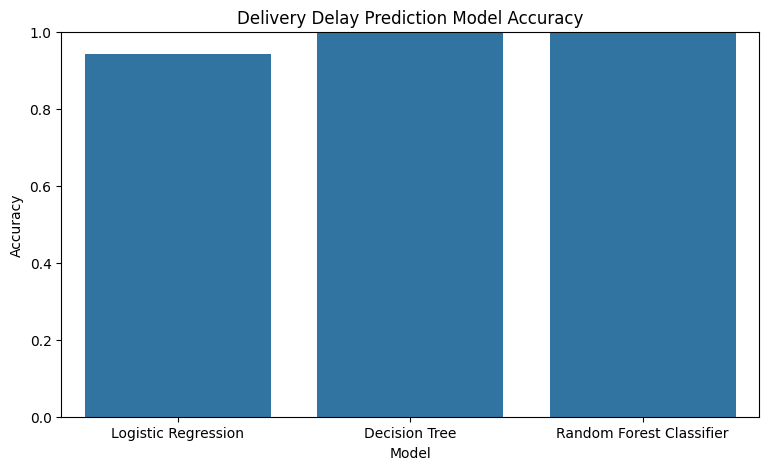

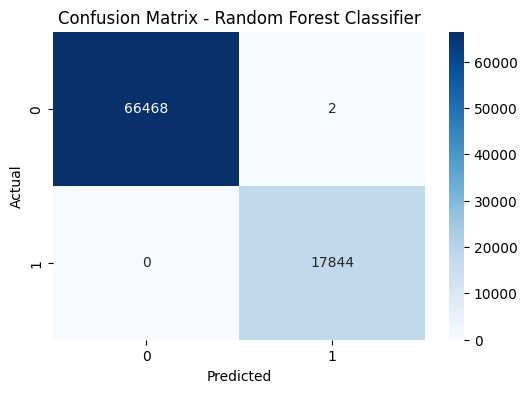

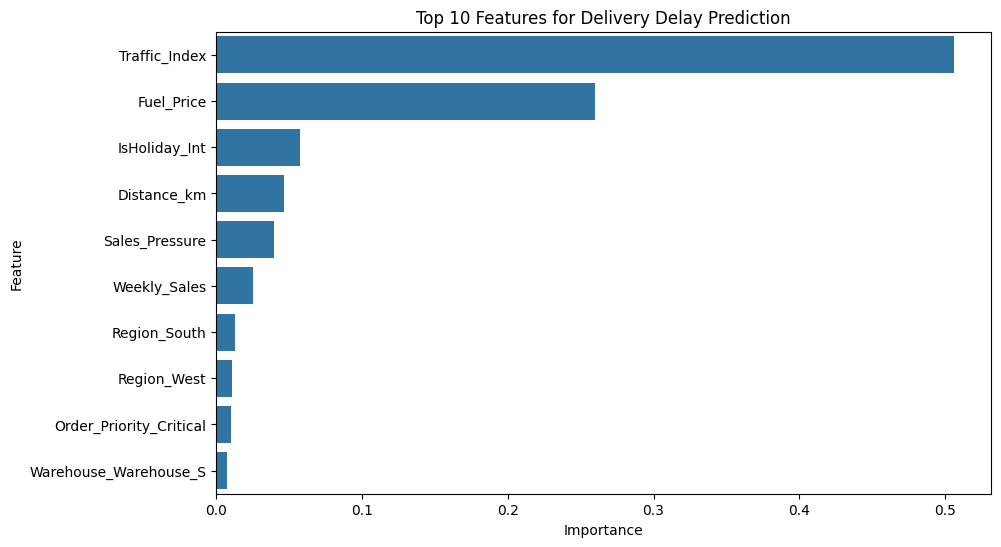

,Feature,Importance
1,Traffic_Index,0.506407
2,Fuel_Price,0.259654
3,IsHoliday_Int,0.057439
0,Distance_km,0.046516
5,Sales_Pressure,0.039547
4,Weekly_Sales,0.024959
9,Region_South,0.012668
10,Region_West,0.011021
16,Order_Priority_Critical,0.009770
12,Warehouse_Warehouse_S,0.007349


In [39]:
# -------------------------------
# Visualize classification model performance
# -------------------------------

plt.figure(figsize=(9, 5))
sns.barplot(data=classification_results, x="Model", y="Accuracy")
plt.title("Delivery Delay Prediction Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test_delay, rf_clf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance for Random Forest Classifier
delay_feature_importance = pd.DataFrame({
    "Feature": X_delay_encoded.columns,
    "Importance": rf_clf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=delay_feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Features for Delivery Delay Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(delay_feature_importance.head(10))

,Store,Dept,Date,Region,Warehouse,Shipping_Mode,Order_Priority,Distance_km,Traffic_Index,Weekly_Sales,Actual_Delivery_Delay,Logistic_Delay_Probability,Decision_Tree_Delay_Probability,Random_Forest_Delay_Probability,Predicted_Delivery_Delay,Delay_Risk_Level
77802,8,92,2010-11-19,East,Warehouse_E,Standard Class,Critical,244,0.101946,68355.89,0,1.253840e-07,0.0,0.0,0,Low Risk
217133,23,3,2010-08-20,Central,Warehouse_C,Second Class,Critical,594,0.102077,59840.16,0,1.478142e-07,0.0,0.0,0,Low Risk
153106,16,38,2012-07-06,Central,Warehouse_C,Second Class,Critical,458,0.266537,49578.07,0,1.455107e-01,0.0,0.0,0,Low Risk
211824,22,35,2011-02-11,Central,Warehouse_C,Second Class,Medium,581,0.361590,3171.70,1,8.989238e-01,1.0,1.0,1,High Risk
112179,12,32,2010-06-04,Central,Warehouse_C,Second Class,High,336,0.101501,8123.58,0,5.759979e-08,0.0,0.0,0,Low Risk


,Region,Warehouse,Shipping_Mode,Order_Priority,Average_Delay_Probability,Actual_Delay_Rate,Number_of_Orders,Average_Distance,Average_Traffic,Total_Sales
11,Central,Warehouse_C,Standard Class,Critical,0.416868,0.417029,3218,447.429149,0.238632,1.788917e+08
131,South,Warehouse_S,Standard Class,Critical,0.399829,0.399858,4219,729.200758,0.236171,1.928536e+08
67,East,Warehouse_E,Second Class,Critical,0.388288,0.388201,1373,276.131100,0.241136,6.537842e+07
7,Central,Warehouse_C,Second Class,Critical,0.385313,0.385086,3433,497.840373,0.231180,1.324435e+08
183,West,Warehouse_W,Same Day,Critical,0.351500,0.351426,1087,1152.424103,0.231554,4.681331e+07
127,South,Warehouse_S,Second Class,Critical,0.348305,0.348326,956,765.936192,0.221715,3.304036e+07
187,West,Warehouse_W,Second Class,Critical,0.340764,0.340764,314,1103.837580,0.227200,1.171289e+07
126,South,Warehouse_S,Second Class,High,0.332749,0.332711,1608,758.383085,0.213796,1.994741e+07
186,West,Warehouse_W,Second Class,High,0.310065,0.310195,461,1105.032538,0.217763,5.881353e+06
10,Central,Warehouse_C,Standard Class,High,0.306245,0.306094,2117,446.494568,0.218009,2.807700e+07


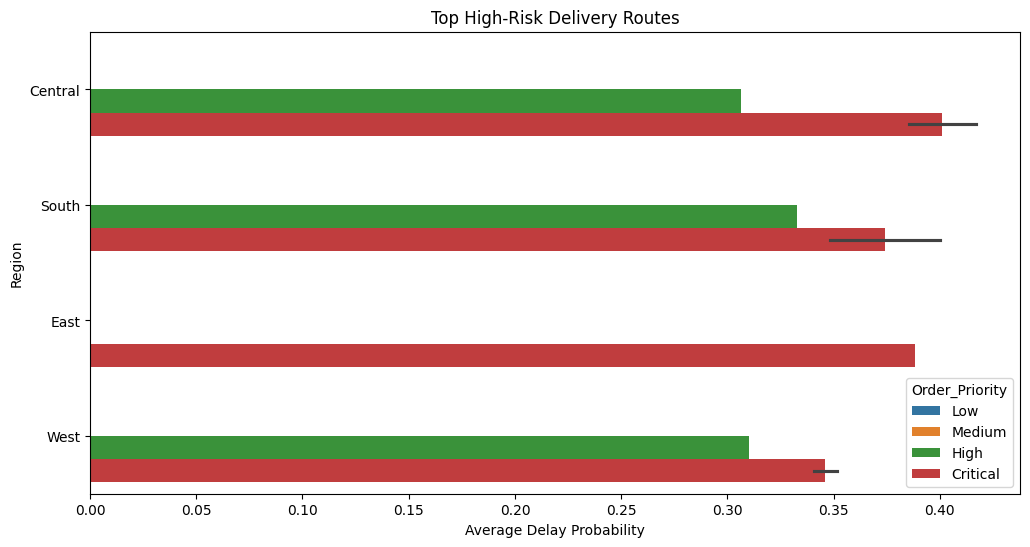

In [44]:
# -------------------------------
# Delay probabilities and high-risk route identification
# FIXED VERSION
# -------------------------------

# Take only original route-related columns
delay_predictions = delivery_df.loc[X_test_delay.index, [
    "Store", "Dept", "Date", "Region", "Warehouse",
    "Shipping_Mode", "Order_Priority", "Distance_km",
    "Traffic_Index", "Weekly_Sales"
]].copy()

# Add actual and predicted results
delay_predictions["Actual_Delivery_Delay"] = y_test_delay.values
delay_predictions["Logistic_Delay_Probability"] = log_prob
delay_predictions["Decision_Tree_Delay_Probability"] = tree_prob
delay_predictions["Random_Forest_Delay_Probability"] = rf_clf_prob
delay_predictions["Predicted_Delivery_Delay"] = rf_clf_pred

# Create risk level based on Random Forest probability
def delay_risk_level(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

delay_predictions["Delay_Risk_Level"] = delay_predictions["Random_Forest_Delay_Probability"].apply(delay_risk_level)

display(delay_predictions.head())

# High-risk routes summary
high_risk_routes = delay_predictions.groupby([
    "Region", "Warehouse", "Shipping_Mode", "Order_Priority"
]).agg(
    Average_Delay_Probability=("Random_Forest_Delay_Probability", "mean"),
    Actual_Delay_Rate=("Actual_Delivery_Delay", "mean"),
    Number_of_Orders=("Store", "count"),
    Average_Distance=("Distance_km", "mean"),
    Average_Traffic=("Traffic_Index", "mean"),
    Total_Sales=("Weekly_Sales", "sum")
).reset_index()

high_risk_routes = high_risk_routes.sort_values(
    by="Average_Delay_Probability",
    ascending=False
)

display(high_risk_routes.head(10))

# Visualize high-risk routes
plt.figure(figsize=(12, 6))
sns.barplot(
    data=high_risk_routes.head(10),
    x="Average_Delay_Probability",
    y="Region",
    hue="Order_Priority"
)
plt.title("Top High-Risk Delivery Routes")
plt.xlabel("Average Delay Probability")
plt.ylabel("Region")
plt.show()

In [45]:
# -------------------------------
# Save delivery delay outputs for Power BI
# -------------------------------

classification_results.to_csv("powerbi_delivery_delay_model_results.csv", index=False)
delay_feature_importance.to_csv("powerbi_delivery_delay_feature_importance.csv", index=False)
delay_predictions.to_csv("powerbi_delivery_delay_predictions.csv", index=False)
high_risk_routes.to_csv("powerbi_high_risk_routes.csv", index=False)

print("Delivery delay prediction outputs saved successfully for Power BI!")

Delivery delay prediction outputs saved successfully for Power BI!


### Task 4 Interpretation

The delivery delay prediction module was completed using Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.

Since the original Walmart retail dataset does not include direct logistics variables such as shipping mode, warehouse, region, distance, traffic, or order priority, these variables were created as proxy logistics features. Store numbers were grouped into regions, each region was connected to a warehouse, store type was used as a proxy for shipping mode, weekly sales level was used to define order priority, and traffic index was estimated from fuel price, holiday weeks, and sales pressure.

The target variable Delivery_Delay was created using the logistic probability formula. The formula included long distance, high traffic, high order priority, holiday weeks, and high fuel price as delay risk factors. As a result, around 21% of observations were classified as delayed deliveries.

Logistic Regression achieved about 94% accuracy. This model is useful because it directly follows the logic of the delay probability formula and gives interpretable results.

Decision Tree and Random Forest Classifier achieved almost perfect accuracy. This is expected because the delay target was generated from clear rule-based logistics factors, and the models were able to learn these patterns very easily.

The feature importance results show that Traffic_Index is the strongest driver of delivery delay prediction. Fuel price, holiday weeks, distance, and sales pressure are also important. This means that delivery risk increases when logistics pressure is high, especially during expensive fuel periods, holiday demand, and long-distance routes.

The high-risk route analysis shows that Critical priority orders in Central, South, East, and West regions have higher delay probabilities. These routes should be monitored carefully. The company can reduce risk by preparing earlier shipments, increasing transport capacity, and improving warehouse coordination before high-demand weeks.

Overall, this module provides delay probabilities, high-risk route identification, and delivery performance insights for Power BI reporting.

## Task 5: Inventory Optimization Module

This module focuses on inventory optimization using K-Means Clustering and ABC Analysis.

The original dataset does not contain direct product-level stock quantities. Therefore, departments are used as product categories, and weekly sales are used as a proxy for product demand.

The module includes:

- K-Means Clustering using demand, sales volatility, store coverage, and average sales
- ABC Analysis based on cumulative sales contribution
- Overstock and understock detection
- Reorder point recommendation

K-Means follows the objective:

J = Σ Σ ‖x − μᵢ‖²

This means that the algorithm groups departments by minimizing the distance between each data point and its cluster center.

In [46]:
# -------------------------------
# TASK 5: INVENTORY OPTIMIZATION
# Department-level inventory summary
# -------------------------------

inventory_df = df.copy()

# Create department-level summary
inventory_summary = inventory_df.groupby("Dept").agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Weekly_Sales=("Weekly_Sales", "mean"),
    Sales_Std=("Weekly_Sales", "std"),
    Number_of_Records=("Weekly_Sales", "count"),
    Store_Coverage=("Store", "nunique"),
    Average_MarkDown=("Total_MarkDown", "mean"),
    Holiday_Sales=("IsHoliday_Int", "sum")
).reset_index()

# Replace missing standard deviation values with 0
inventory_summary["Sales_Std"] = inventory_summary["Sales_Std"].fillna(0)

# Demand volatility: how unstable the demand is
inventory_summary["Demand_Volatility"] = (
    inventory_summary["Sales_Std"] / inventory_summary["Average_Weekly_Sales"]
)

inventory_summary["Demand_Volatility"] = inventory_summary["Demand_Volatility"].replace([np.inf, -np.inf], 0)
inventory_summary["Demand_Volatility"] = inventory_summary["Demand_Volatility"].fillna(0)

# Average weekly demand proxy
inventory_summary["Average_Weekly_Demand"] = inventory_summary["Average_Weekly_Sales"]

display(inventory_summary.head())
print("Inventory summary shape:", inventory_summary.shape)

,Dept,Total_Sales,Average_Weekly_Sales,Sales_Std,Number_of_Records,Store_Coverage,Average_MarkDown,Holiday_Sales,Demand_Volatility,Average_Weekly_Demand
0,1,1.236388e+08,19213.485088,15102.373853,6435,45,6267.753417,450,0.786030,19213.485088
1,2,2.806112e+08,43607.020113,25176.756920,6435,45,6267.753417,450,0.577356,43607.020113
2,3,7.589245e+07,11793.698516,12790.994371,6435,45,6267.753417,450,1.084562,11793.698516
3,4,1.671467e+08,25974.630238,13261.140706,6435,45,6267.753417,450,0.510542,25974.630238
4,5,1.356074e+08,21365.583515,19988.452259,6347,45,6354.654678,443,0.935544,21365.583515


Inventory summary shape: (81, 10)


,Dept,Total_Sales,Average_Weekly_Sales,Sales_Std,Number_of_Records,Store_Coverage,Average_MarkDown,Holiday_Sales,Demand_Volatility,Average_Weekly_Demand,Cumulative_Sales,Cumulative_Percentage,ABC_Category
73,92,4.839433e+08,75204.870531,49413.732570,6435,45,6267.753417,450,0.657055,75204.870531,4.839433e+08,7.183132,A
76,95,4.493202e+08,69824.423080,38200.536452,6435,45,6267.753417,450,0.547094,69824.423080,9.332635e+08,13.852355,A
36,38,3.931181e+08,61090.619568,23966.913901,6435,45,6267.753417,450,0.392317,61090.619568,1.326382e+09,19.687376,A
60,72,3.057252e+08,50566.515417,44710.982652,6046,45,6629.312360,425,0.884201,50566.515417,1.632107e+09,24.225230,A
71,90,2.910685e+08,45232.084488,32462.020077,6435,45,6267.753417,450,0.717677,45232.084488,1.923175e+09,28.545536,A
38,40,2.889360e+08,44900.702727,21903.876911,6435,45,6267.753417,450,0.487829,44900.702727,2.212111e+09,32.834190,A
1,2,2.806112e+08,43607.020113,25176.756920,6435,45,6267.753417,450,0.577356,43607.020113,2.492722e+09,36.999279,A
72,91,2.167817e+08,33687.910758,26247.462296,6435,45,6267.753417,450,0.779136,33687.910758,2.709504e+09,40.216952,A
12,13,1.973216e+08,30663.802634,16237.526432,6435,45,6267.753417,450,0.529534,30663.802634,2.906826e+09,43.145781,A
7,8,1.942808e+08,30191.263517,18189.717268,6435,45,6267.753417,450,0.602483,30191.263517,3.101107e+09,46.029475,A


,ABC_Category,Number_of_Departments,Total_Sales,Average_Weekly_Sales,Sales_Share_%
0,A,28,5.344872e+09,30110.736544,79.333509
1,B,20,1.046253e+09,9083.576458,15.529448
2,C,33,3.460938e+08,3387.746438,5.137043


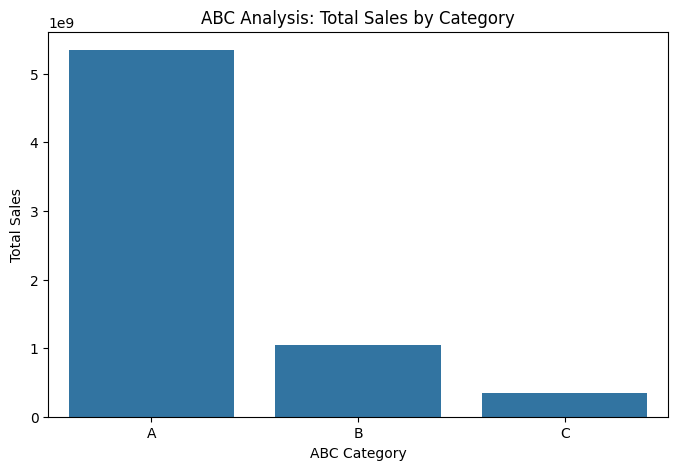

In [47]:
# -------------------------------
# ABC ANALYSIS
# -------------------------------

# Sort departments by total sales
abc_df = inventory_summary.sort_values(by="Total_Sales", ascending=False).copy()

# Calculate cumulative sales and cumulative percentage
abc_df["Cumulative_Sales"] = abc_df["Total_Sales"].cumsum()
abc_df["Cumulative_Percentage"] = (
    abc_df["Cumulative_Sales"] / abc_df["Total_Sales"].sum()
) * 100

# Assign ABC categories
def assign_abc_category(value):
    if value <= 80:
        return "A"
    elif value <= 95:
        return "B"
    else:
        return "C"

abc_df["ABC_Category"] = abc_df["Cumulative_Percentage"].apply(assign_abc_category)

display(abc_df.head(15))

# ABC category summary
abc_summary = abc_df.groupby("ABC_Category").agg(
    Number_of_Departments=("Dept", "count"),
    Total_Sales=("Total_Sales", "sum"),
    Average_Weekly_Sales=("Average_Weekly_Sales", "mean")
).reset_index()

abc_summary["Sales_Share_%"] = (
    abc_summary["Total_Sales"] / abc_summary["Total_Sales"].sum()
) * 100

display(abc_summary)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=abc_summary, x="ABC_Category", y="Total_Sales")
plt.title("ABC Analysis: Total Sales by Category")
plt.xlabel("ABC Category")
plt.ylabel("Total Sales")
plt.show()

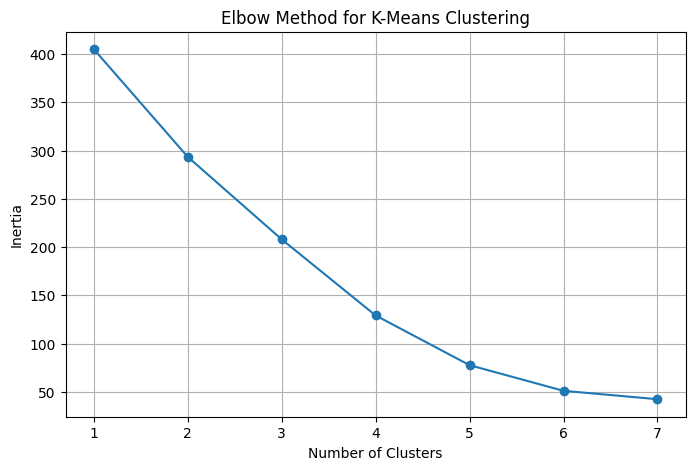

,Dept,Total_Sales,Average_Weekly_Sales,Demand_Volatility,ABC_Category,Cluster
73,92,4.839433e+08,75204.870531,0.657055,A,2
76,95,4.493202e+08,69824.423080,0.547094,A,2
36,38,3.931181e+08,61090.619568,0.392317,A,2
60,72,3.057252e+08,50566.515417,0.884201,A,2
71,90,2.910685e+08,45232.084488,0.717677,A,2
38,40,2.889360e+08,44900.702727,0.487829,A,2
1,2,2.806112e+08,43607.020113,0.577356,A,2
72,91,2.167817e+08,33687.910758,0.779136,A,2
12,13,1.973216e+08,30663.802634,0.529534,A,2
7,8,1.942808e+08,30191.263517,0.602483,A,2


,Cluster,Number_of_Departments,Total_Sales,Average_Weekly_Sales,Average_Demand_Volatility,Average_Store_Coverage,Average_MarkDown
0,0,9,2.141413e+07,5922.850711,-3.626798,20.111111,12964.585619
1,1,61,3.424786e+09,9260.443142,0.878393,43.524590,6642.545290
2,2,11,3.291019e+09,47125.008800,0.630472,45.000000,6336.781958


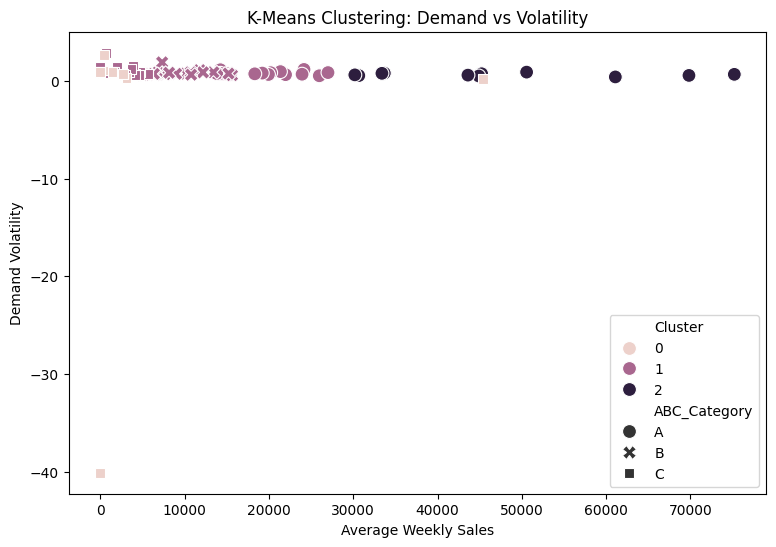

In [48]:
# -------------------------------
# K-MEANS CLUSTERING
# -------------------------------

# Features for clustering
cluster_features = [
    "Total_Sales",
    "Average_Weekly_Sales",
    "Demand_Volatility",
    "Store_Coverage",
    "Average_MarkDown"
]

X_cluster = abc_df[cluster_features]

# Scale features before K-Means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow method to check suitable number of clusters
inertia_values = []

for k in range(1, 8):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inertia_values.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertia_values, marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Final K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
abc_df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

display(abc_df[["Dept", "Total_Sales", "Average_Weekly_Sales", "Demand_Volatility", "ABC_Category", "Cluster"]].head(15))

# Cluster summary
cluster_summary = abc_df.groupby("Cluster").agg(
    Number_of_Departments=("Dept", "count"),
    Total_Sales=("Total_Sales", "sum"),
    Average_Weekly_Sales=("Average_Weekly_Sales", "mean"),
    Average_Demand_Volatility=("Demand_Volatility", "mean"),
    Average_Store_Coverage=("Store_Coverage", "mean"),
    Average_MarkDown=("Average_MarkDown", "mean")
).reset_index()

display(cluster_summary)

# Visualization of clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=abc_df,
    x="Average_Weekly_Sales",
    y="Demand_Volatility",
    hue="Cluster",
    style="ABC_Category",
    s=100
)
plt.title("K-Means Clustering: Demand vs Volatility")
plt.xlabel("Average Weekly Sales")
plt.ylabel("Demand Volatility")
plt.show()

,Stock_Status,Number_of_Departments,Total_Sales,Average_Weekly_Demand,Average_Demand_Volatility
0,Normal Stock,34,4.274721e+09,21123.344107,0.755293
1,Overstock Risk,36,7.704013e+08,4038.515144,-0.206610
2,Understock Risk,11,1.692097e+09,24817.049091,0.875819


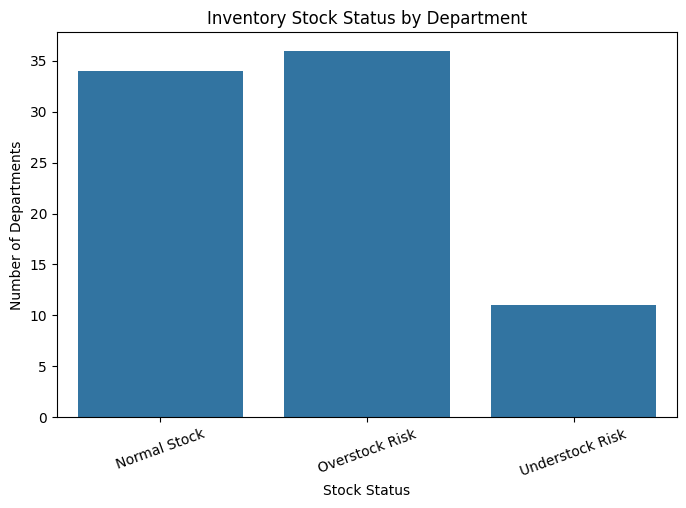

,Dept,ABC_Category,Cluster,Average_Weekly_Demand,Demand_Volatility,Average_MarkDown,Stock_Status
73,92,A,2,75204.870531,0.657055,6267.753417,Normal Stock
76,95,A,2,69824.423080,0.547094,6267.753417,Normal Stock
36,38,A,2,61090.619568,0.392317,6267.753417,Normal Stock
60,72,A,2,50566.515417,0.884201,6629.312360,Understock Risk
71,90,A,2,45232.084488,0.717677,6267.753417,Normal Stock
38,40,A,2,44900.702727,0.487829,6267.753417,Normal Stock
1,2,A,2,43607.020113,0.577356,6267.753417,Normal Stock
72,91,A,2,33687.910758,0.779136,6267.753417,Understock Risk
12,13,A,2,30663.802634,0.529534,6267.753417,Normal Stock
7,8,A,2,30191.263517,0.602483,6267.753417,Normal Stock


In [49]:
# -------------------------------
# OVERSTOCK AND UNDERSTOCK DETECTION
# -------------------------------

# Demand level compared with average department demand
avg_department_demand = abc_df["Average_Weekly_Demand"].mean()

# Simple stock status logic:
# High demand + high volatility = understock risk
# Low demand + high markdown = overstock risk
def stock_status(row):
    if row["Average_Weekly_Demand"] > avg_department_demand and row["Demand_Volatility"] > abc_df["Demand_Volatility"].median():
        return "Understock Risk"
    elif row["Average_Weekly_Demand"] < avg_department_demand and row["Average_MarkDown"] > abc_df["Average_MarkDown"].median():
        return "Overstock Risk"
    else:
        return "Normal Stock"

abc_df["Stock_Status"] = abc_df.apply(stock_status, axis=1)

stock_status_summary = abc_df.groupby("Stock_Status").agg(
    Number_of_Departments=("Dept", "count"),
    Total_Sales=("Total_Sales", "sum"),
    Average_Weekly_Demand=("Average_Weekly_Demand", "mean"),
    Average_Demand_Volatility=("Demand_Volatility", "mean")
).reset_index()

display(stock_status_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=stock_status_summary, x="Stock_Status", y="Number_of_Departments")
plt.title("Inventory Stock Status by Department")
plt.xlabel("Stock Status")
plt.ylabel("Number of Departments")
plt.xticks(rotation=20)
plt.show()

display(abc_df[[
    "Dept", "ABC_Category", "Cluster", "Average_Weekly_Demand",
    "Demand_Volatility", "Average_MarkDown", "Stock_Status"
]].head(20))

,Dept,ABC_Category,Cluster,Stock_Status,Average_Weekly_Demand,Lead_Time_Weeks,Safety_Stock,Reorder_Point,Reorder_Recommendation
73,92,A,2,Normal Stock,75204.870531,2,24706.866285,175116.607348,Monitor weekly and maintain safety stock
76,95,A,2,Normal Stock,69824.423080,2,19100.268226,158749.114386,Monitor weekly and maintain safety stock
36,38,A,2,Normal Stock,61090.619568,2,11983.456951,134164.696087,Monitor weekly and maintain safety stock
60,72,A,2,Understock Risk,50566.515417,2,22355.491326,123488.522159,Increase reorder quantity
71,90,A,2,Normal Stock,45232.084488,2,16231.010039,106695.179015,Monitor weekly and maintain safety stock
38,40,A,2,Normal Stock,44900.702727,2,10951.938456,100753.343910,Monitor weekly and maintain safety stock
1,2,A,2,Normal Stock,43607.020113,2,12588.378460,99802.418687,Monitor weekly and maintain safety stock
72,91,A,2,Understock Risk,33687.910758,2,13123.731148,80499.552665,Increase reorder quantity
12,13,A,2,Normal Stock,30663.802634,2,8118.763216,69446.368484,Monitor weekly and maintain safety stock
7,8,A,2,Normal Stock,30191.263517,2,9094.858634,69477.385667,Monitor weekly and maintain safety stock


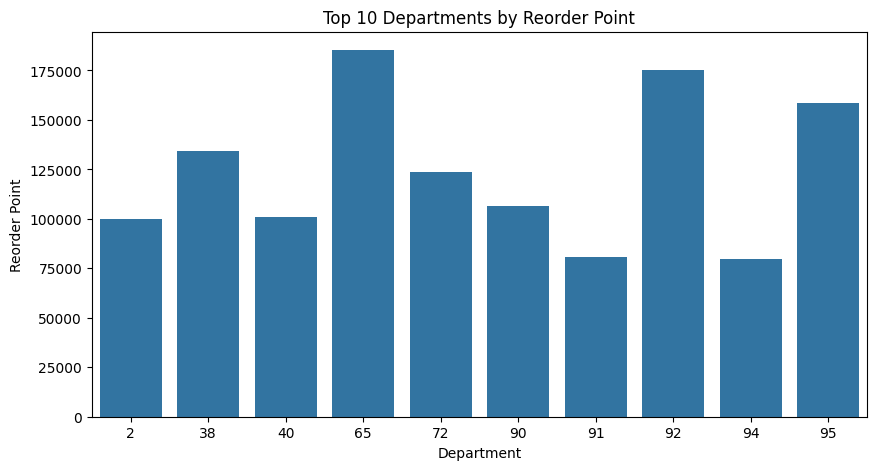

In [50]:
# -------------------------------
# REORDER POINT RECOMMENDATIONS
# -------------------------------

# Since the dataset has weekly sales, we estimate reorder point using weekly demand.
# Formula:
# Reorder Point = Average Demand During Lead Time + Safety Stock

# Proxy lead time based on ABC category
def lead_time_weeks(category):
    if category == "A":
        return 2
    elif category == "B":
        return 3
    else:
        return 4

abc_df["Lead_Time_Weeks"] = abc_df["ABC_Category"].apply(lead_time_weeks)

# Safety stock uses demand volatility
abc_df["Safety_Stock"] = abc_df["Sales_Std"] * 0.5

# Reorder point
abc_df["Reorder_Point"] = (
    abc_df["Average_Weekly_Demand"] * abc_df["Lead_Time_Weeks"]
    + abc_df["Safety_Stock"]
)

# Recommended action
def reorder_recommendation(row):
    if row["Stock_Status"] == "Understock Risk":
        return "Increase reorder quantity"
    elif row["Stock_Status"] == "Overstock Risk":
        return "Reduce reorder quantity"
    elif row["ABC_Category"] == "A":
        return "Monitor weekly and maintain safety stock"
    elif row["ABC_Category"] == "B":
        return "Monitor bi-weekly"
    else:
        return "Low priority, avoid excess stock"

abc_df["Reorder_Recommendation"] = abc_df.apply(reorder_recommendation, axis=1)

display(abc_df[[
    "Dept", "ABC_Category", "Cluster", "Stock_Status",
    "Average_Weekly_Demand", "Lead_Time_Weeks",
    "Safety_Stock", "Reorder_Point", "Reorder_Recommendation"
]].head(20))

# Top departments by reorder point
top_reorder = abc_df.sort_values(by="Reorder_Point", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_reorder, x="Dept", y="Reorder_Point")
plt.title("Top 10 Departments by Reorder Point")
plt.xlabel("Department")
plt.ylabel("Reorder Point")
plt.show()

In [51]:
# -------------------------------
# SAVE INVENTORY OUTPUTS FOR POWER BI
# -------------------------------

abc_df.to_csv("powerbi_inventory_abc_kmeans_reorder.csv", index=False)
abc_summary.to_csv("powerbi_abc_summary.csv", index=False)
cluster_summary.to_csv("powerbi_inventory_cluster_summary.csv", index=False)
stock_status_summary.to_csv("powerbi_stock_status_summary.csv", index=False)
top_reorder.to_csv("powerbi_top_reorder_departments.csv", index=False)

print("Inventory optimization outputs saved successfully for Power BI!")

Inventory optimization outputs saved successfully for Power BI!


### Task 5 Interpretation

The inventory optimization module was completed using ABC Analysis, K-Means Clustering, overstock and understock detection, and reorder point recommendations.

Since the dataset does not contain direct product stock quantities, departments were used as product categories, and weekly sales were used as a proxy for demand. This allows the analysis to connect retail sales behavior with inventory planning.

ABC Analysis shows that Category A includes 28 departments and generates around 79.33% of total sales. These departments are the most important for the business because they create the largest share of revenue. Category B includes 20 departments and contributes around 15.53% of sales, while Category C includes 33 departments and contributes only around 5.14%. This confirms the classic ABC logic: a smaller group of high-value departments drives most of the sales.

K-Means Clustering was applied using total sales, average weekly sales, demand volatility, store coverage, and average markdown. The clustering objective is to minimize the distance between each department and its cluster center. The results show that departments can be grouped by demand size and demand volatility. High-sales departments are separated from lower-sales departments, which helps create different inventory strategies for different product groups.

The stock status analysis identified 34 departments as Normal Stock, 36 departments as Overstock Risk, and 11 departments as Understock Risk. Overstock risk means that departments may have lower demand but higher markdown activity, which can indicate slow-moving stock. Understock risk means that departments have high demand and high volatility, so they may need faster replenishment.

Reorder points were calculated using average weekly demand, estimated lead time, and safety stock. Category A departments were assigned shorter lead times because they are more important for revenue. The highest reorder point departments include 92, 95, 38, 72, and 90. These departments should be monitored weekly and should maintain enough safety stock to avoid stockouts.

Overall, this module provides data-driven inventory categories, cluster groups, stock risk status, reorder points, and reorder recommendations. These outputs can be used in Power BI for an Inventory Intelligence dashboard.

## Task 6: Supplier & Transportation Analytics

This module focuses on supplier reliability, lead times, transportation costs, route efficiency, fuel pressure, delay trends, logistics bottlenecks, and supply chain risks.

The original Walmart dataset does not contain direct supplier names, transportation costs, or real route data. Therefore, a proxy supply chain network is created using the logistics features from Task 4.

In this module:

- Warehouses are treated as suppliers / distribution partners
- Regions represent transport zones
- Shipping mode represents delivery service type
- Distance, fuel price, traffic index, and delay probability are used to estimate transportation performance
- Delivery delay is used as the main reliability indicator

The goal is to create supplier rankings, identify bottlenecks, evaluate cost efficiency, and provide risk insights for the supply chain network.

In [55]:
# -------------------------------
# TASK 6: SUPPLIER & TRANSPORTATION ANALYTICS
# FAST VERSION
# -------------------------------

transport_df = delivery_df.copy()

# Supplier proxy:
# Each warehouse is treated as an external supply / distribution partner
transport_df["Supplier"] = transport_df["Warehouse"]

# Estimated transportation cost
# Cost is based on distance, fuel price, traffic pressure, and shipping mode
shipping_cost_multiplier = {
    "Standard Class": 1.00,
    "Second Class": 1.20,
    "Same Day": 1.60
}

transport_df["Shipping_Cost_Multiplier"] = transport_df["Shipping_Mode"].map(shipping_cost_multiplier)

transport_df["Estimated_Transport_Cost"] = (
    transport_df["Distance_km"]
    * transport_df["Fuel_Price"]
    * transport_df["Shipping_Cost_Multiplier"]
    * (1 + transport_df["Traffic_Index"])
)

# Fast estimated lead time calculation without apply(axis=1)
transport_df["Mode_Adjustment"] = 1.0

transport_df.loc[transport_df["Shipping_Mode"] == "Same Day", "Mode_Adjustment"] = -0.5
transport_df.loc[transport_df["Shipping_Mode"] == "Second Class", "Mode_Adjustment"] = 0.5
transport_df.loc[transport_df["Shipping_Mode"] == "Standard Class", "Mode_Adjustment"] = 1.0

transport_df["Estimated_Lead_Time_Days"] = (
    transport_df["Distance_km"] / 250
    + transport_df["Mode_Adjustment"]
    + transport_df["Traffic_Index"] * 3
)

# Minimum lead time should be 1 day
transport_df["Estimated_Lead_Time_Days"] = transport_df["Estimated_Lead_Time_Days"].clip(lower=1)

# Route efficiency
# Higher sales per transport cost means better route efficiency
transport_df["Route_Efficiency"] = (
    transport_df["Weekly_Sales"] / (transport_df["Estimated_Transport_Cost"] + 1)
)

# Fuel pressure level
q25 = transport_df["Fuel_Price"].quantile(0.25)
q75 = transport_df["Fuel_Price"].quantile(0.75)

transport_df["Fuel_Pressure_Level"] = "Normal Fuel Pressure"
transport_df.loc[transport_df["Fuel_Price"] >= q75, "Fuel_Pressure_Level"] = "High Fuel Pressure"
transport_df.loc[transport_df["Fuel_Price"] <= q25, "Fuel_Pressure_Level"] = "Low Fuel Pressure"

display(transport_df[[
    "Store", "Dept", "Date", "Region", "Supplier", "Shipping_Mode",
    "Distance_km", "Fuel_Price", "Traffic_Index",
    "Estimated_Transport_Cost", "Estimated_Lead_Time_Days",
    "Route_Efficiency", "Delivery_Delay"
]].head())

,Store,Dept,Date,Region,Supplier,Shipping_Mode,Distance_km,Fuel_Price,Traffic_Index,Estimated_Transport_Cost,Estimated_Lead_Time_Days,Route_Efficiency,Delivery_Delay
0,1,1,2010-02-05,East,Warehouse_E,Standard Class,78,2.572,0.037180,208.074960,1.423541,119.213224,0
1,1,1,2010-02-12,East,Warehouse_E,Standard Class,78,2.548,0.244469,247.330829,2.045408,185.395789,0
2,1,1,2010-02-19,East,Warehouse_E,Standard Class,78,2.514,0.035109,202.976680,1.417328,203.923066,0
3,1,1,2010-02-26,East,Warehouse_E,Standard Class,78,2.561,0.031812,206.112782,1.407437,93.685864,0
4,1,1,2010-03-05,East,Warehouse_E,Standard Class,78,2.625,0.046027,214.174068,1.450082,101.442986,0


,Supplier,Number_of_Orders,Total_Sales,Average_Delay_Rate,Average_Delay_Probability,Average_Lead_Time_Days,Average_Transport_Cost,Average_Route_Efficiency,Average_Fuel_Price,Average_Traffic_Index,Reliability_Score
1,Warehouse_E,107901,1.879067e+09,0.107330,0.198664,2.170419,899.670598,26.434152,3.255581,0.183971,0.816887
0,Warehouse_C,118968,2.128065e+09,0.213099,0.272867,3.212737,2246.057530,8.906103,3.414796,0.216120,0.532996
3,Warehouse_W,81283,1.035252e+09,0.224955,0.364373,5.167095,5710.930260,2.744241,3.348720,0.199879,0.428298
2,Warehouse_S,113418,1.694835e+09,0.299811,0.401532,4.444656,3440.592031,4.787226,3.413762,0.214221,0.425662


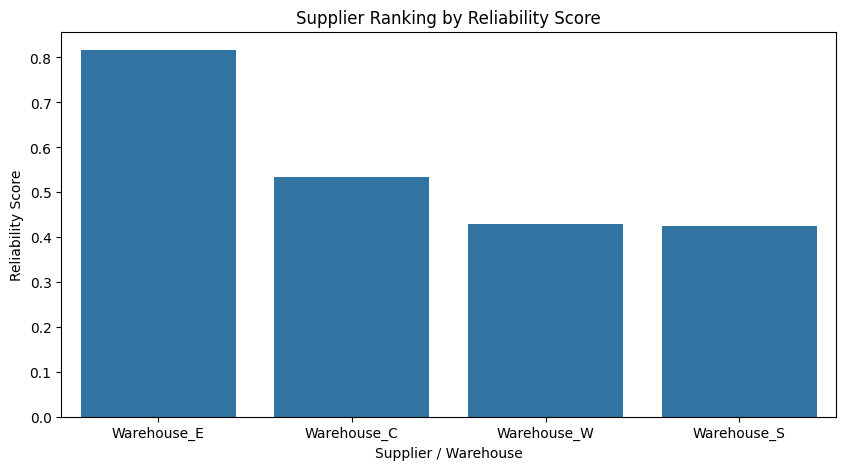

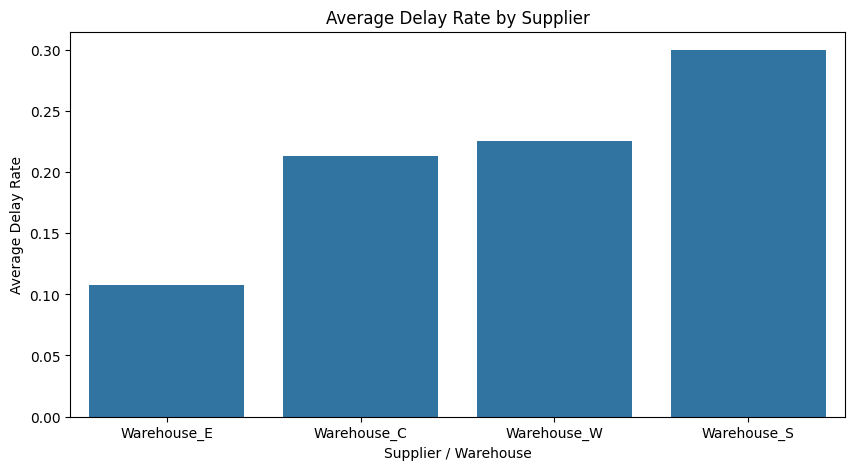

In [56]:
# -------------------------------
# SUPPLIER RELIABILITY AND RANKING
# -------------------------------

supplier_summary = transport_df.groupby("Supplier").agg(
    Number_of_Orders=("Store", "count"),
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Delay_Rate=("Delivery_Delay", "mean"),
    Average_Delay_Probability=("Delay_Probability_Formula", "mean"),
    Average_Lead_Time_Days=("Estimated_Lead_Time_Days", "mean"),
    Average_Transport_Cost=("Estimated_Transport_Cost", "mean"),
    Average_Route_Efficiency=("Route_Efficiency", "mean"),
    Average_Fuel_Price=("Fuel_Price", "mean"),
    Average_Traffic_Index=("Traffic_Index", "mean")
).reset_index()

# Reliability score: higher is better
# Lower delay, lower lead time, and higher efficiency improve reliability
supplier_summary["Reliability_Score"] = (
    (1 - supplier_summary["Average_Delay_Rate"]) * 0.45
    + (1 / supplier_summary["Average_Lead_Time_Days"]) * 0.25
    + (supplier_summary["Average_Route_Efficiency"] / supplier_summary["Average_Route_Efficiency"].max()) * 0.30
)

supplier_summary = supplier_summary.sort_values(by="Reliability_Score", ascending=False)

display(supplier_summary)

# Visualization: supplier ranking
plt.figure(figsize=(10, 5))
sns.barplot(data=supplier_summary, x="Supplier", y="Reliability_Score")
plt.title("Supplier Ranking by Reliability Score")
plt.xlabel("Supplier / Warehouse")
plt.ylabel("Reliability Score")
plt.show()

# Visualization: supplier delay rate
plt.figure(figsize=(10, 5))
sns.barplot(data=supplier_summary, x="Supplier", y="Average_Delay_Rate")
plt.title("Average Delay Rate by Supplier")
plt.xlabel("Supplier / Warehouse")
plt.ylabel("Average Delay Rate")
plt.show()

,Region,Supplier,Shipping_Mode,Number_of_Orders,Total_Sales,Average_Distance,Average_Transport_Cost,Average_Lead_Time_Days,Average_Route_Efficiency,Delay_Rate,Average_Traffic_Index,Average_Fuel_Price
7,West,Warehouse_W,Same Day,35441,3.427866e+08,1157.579329,7651.495101,4.750786,1.318604,0.237211,0.206823,3.392686
4,South,Warehouse_S,Same Day,7156,6.271689e+07,910.176076,5559.794543,3.659299,1.643313,0.112493,0.172865,3.225819
8,West,Warehouse_W,Second Class,9637,1.123953e+08,1105.825464,5555.268874,5.563641,2.178982,0.294594,0.213446,3.419065
9,West,Warehouse_W,Standard Class,36205,5.800700e+08,975.163679,3852.749077,5.469068,4.290253,0.194421,0.189471,3.286956
5,South,Warehouse_S,Second Class,28787,3.097234e+08,751.864557,3787.902632,4.150358,2.973079,0.306388,0.214300,3.426057
6,South,Warehouse_S,Standard Class,77475,1.322395e+09,743.128028,3115.802829,4.626547,5.751687,0.314669,0.218012,3.426553
0,Central,Warehouse_C,Second Class,78092,1.044514e+09,485.179506,2421.383594,3.078551,5.724863,0.195692,0.212611,3.410233
1,Central,Warehouse_C,Standard Class,40876,1.083550e+09,450.156131,1911.103938,3.469094,14.983738,0.246355,0.222823,3.423513
2,East,Warehouse_E,Second Class,46979,5.340676e+08,229.189106,1105.311998,1.986359,9.776488,0.112689,0.189868,3.302290
3,East,Warehouse_E,Standard Class,60922,1.344999e+09,193.520370,741.093608,2.312354,39.279436,0.103198,0.179424,3.219562


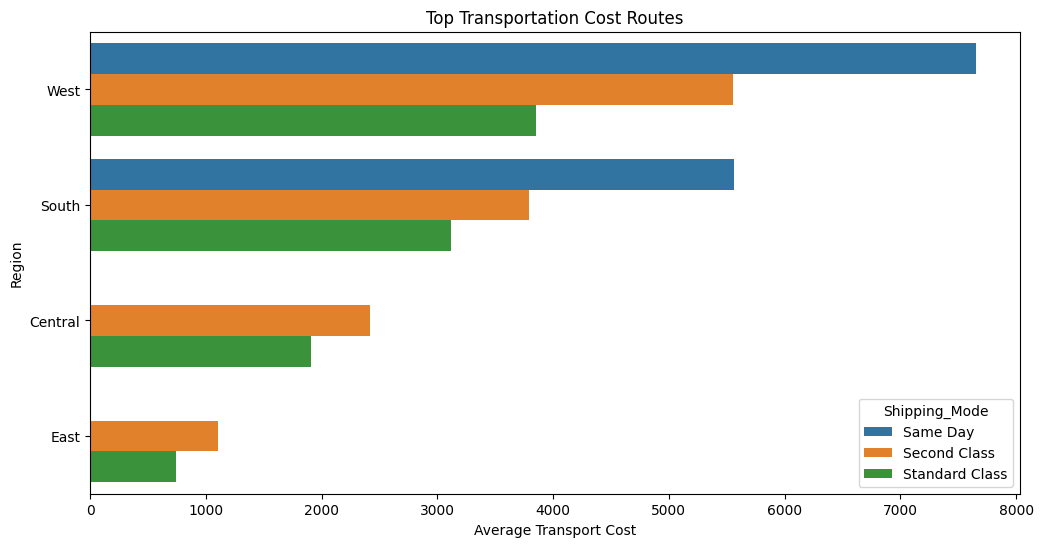

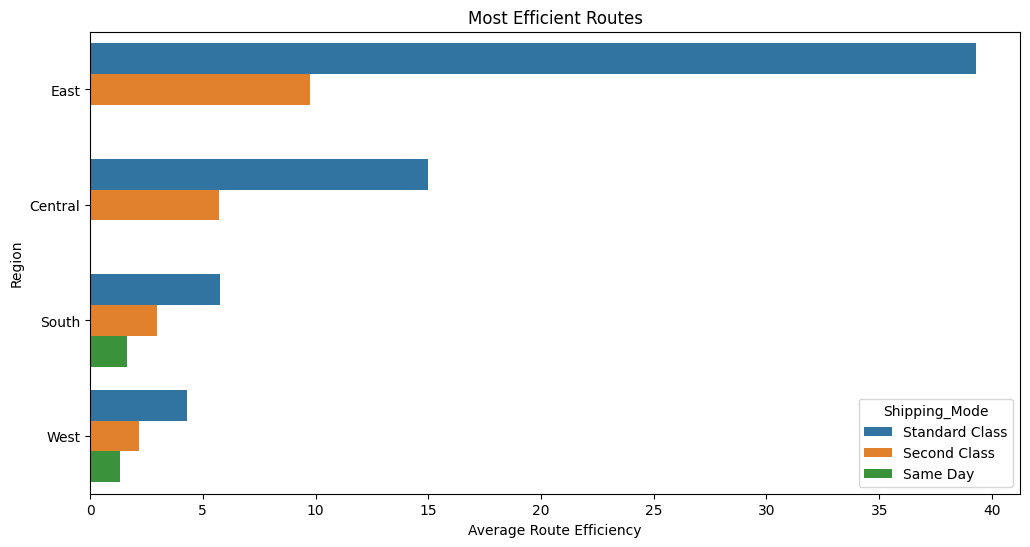

In [57]:
# -------------------------------
# TRANSPORTATION COST AND ROUTE EFFICIENCY
# -------------------------------

route_summary = transport_df.groupby([
    "Region", "Supplier", "Shipping_Mode"
]).agg(
    Number_of_Orders=("Store", "count"),
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Distance=("Distance_km", "mean"),
    Average_Transport_Cost=("Estimated_Transport_Cost", "mean"),
    Average_Lead_Time_Days=("Estimated_Lead_Time_Days", "mean"),
    Average_Route_Efficiency=("Route_Efficiency", "mean"),
    Delay_Rate=("Delivery_Delay", "mean"),
    Average_Traffic_Index=("Traffic_Index", "mean"),
    Average_Fuel_Price=("Fuel_Price", "mean")
).reset_index()

route_summary = route_summary.sort_values(by="Average_Transport_Cost", ascending=False)

display(route_summary.head(15))

# Top expensive routes
top_cost_routes = route_summary.sort_values(
    by="Average_Transport_Cost",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_cost_routes,
    x="Average_Transport_Cost",
    y="Region",
    hue="Shipping_Mode"
)
plt.title("Top Transportation Cost Routes")
plt.xlabel("Average Transport Cost")
plt.ylabel("Region")
plt.show()

# Most efficient routes
top_efficient_routes = route_summary.sort_values(
    by="Average_Route_Efficiency",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_efficient_routes,
    x="Average_Route_Efficiency",
    y="Region",
    hue="Shipping_Mode"
)
plt.title("Most Efficient Routes")
plt.xlabel("Average Route Efficiency")
plt.ylabel("Region")
plt.show()

,Date,Average_Fuel_Price,Average_Delay_Rate,Average_Traffic_Index,Average_Transport_Cost
0,2010-02-05,2.717869,0.000000,0.061778,2030.822831
1,2010-02-12,2.696102,0.223951,0.257139,2376.758048
2,2010-02-19,2.673666,0.000000,0.052565,1980.954438
3,2010-02-26,2.685642,0.000000,0.054210,1984.727890
4,2010-03-05,2.731816,0.000000,0.064049,2038.602793


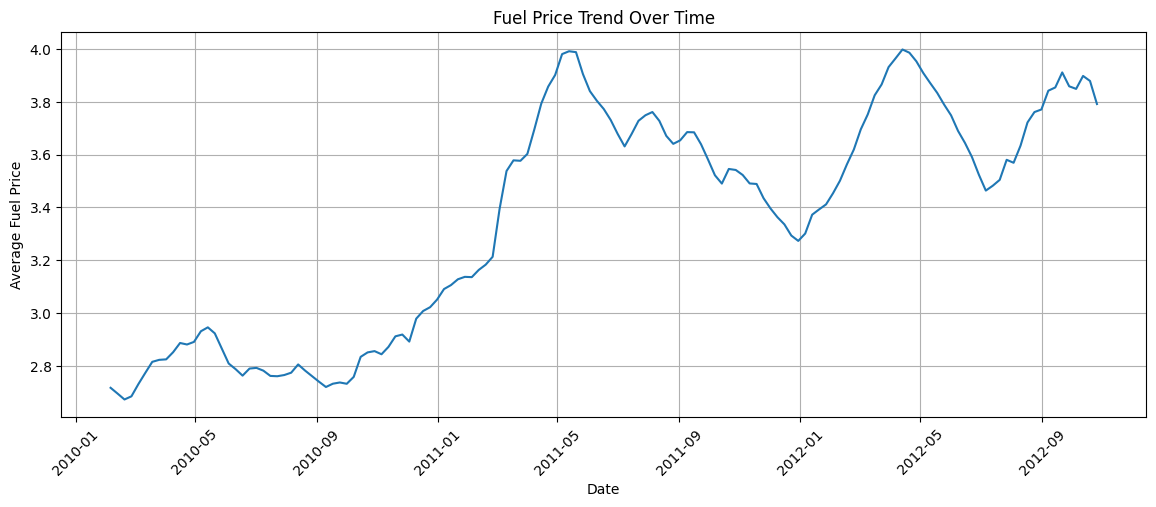

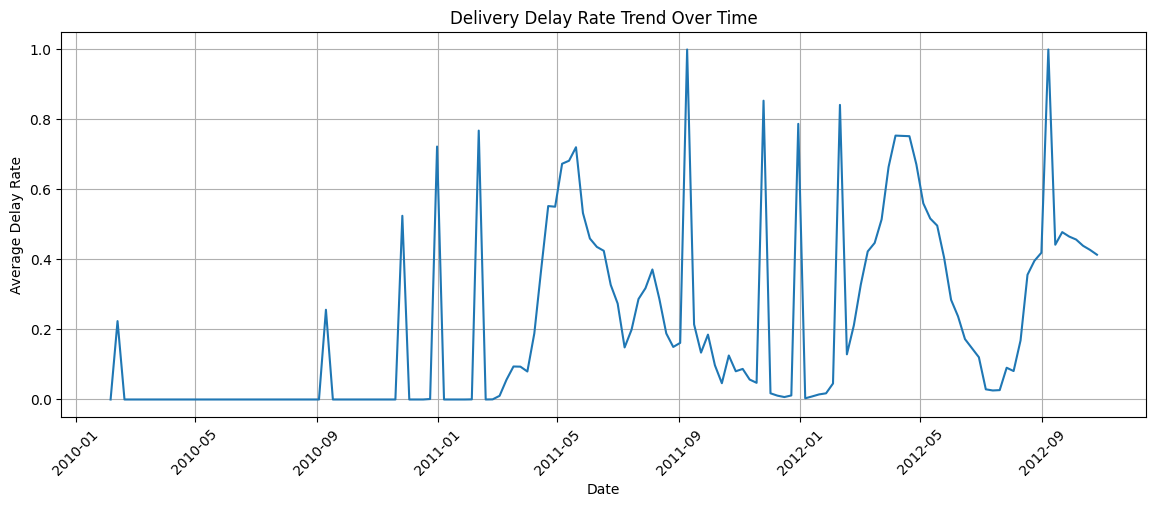

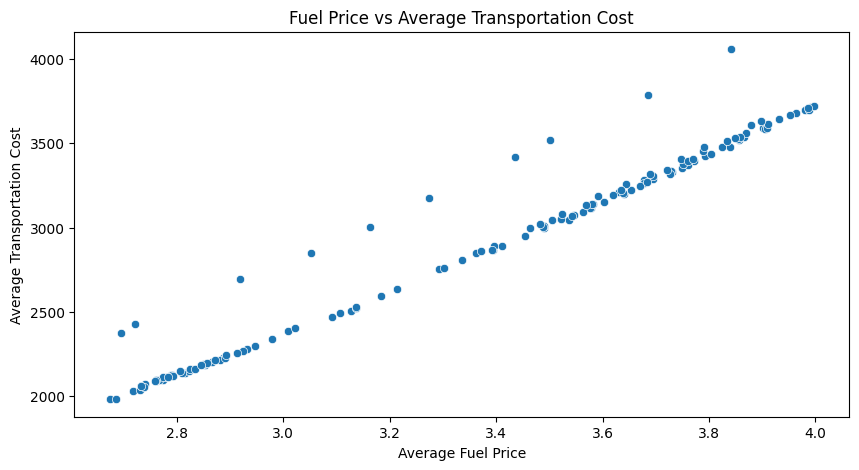

In [58]:
# -------------------------------
# FUEL AND DELAY TRENDS
# -------------------------------

fuel_delay_trend = transport_df.groupby("Date").agg(
    Average_Fuel_Price=("Fuel_Price", "mean"),
    Average_Delay_Rate=("Delivery_Delay", "mean"),
    Average_Traffic_Index=("Traffic_Index", "mean"),
    Average_Transport_Cost=("Estimated_Transport_Cost", "mean")
).reset_index()

display(fuel_delay_trend.head())

# Fuel price trend
plt.figure(figsize=(14, 5))
plt.plot(fuel_delay_trend["Date"], fuel_delay_trend["Average_Fuel_Price"])
plt.title("Fuel Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Fuel Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Delay rate trend
plt.figure(figsize=(14, 5))
plt.plot(fuel_delay_trend["Date"], fuel_delay_trend["Average_Delay_Rate"])
plt.title("Delivery Delay Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Fuel price vs transport cost
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=fuel_delay_trend,
    x="Average_Fuel_Price",
    y="Average_Transport_Cost"
)
plt.title("Fuel Price vs Average Transportation Cost")
plt.xlabel("Average Fuel Price")
plt.ylabel("Average Transportation Cost")
plt.show()

,Bottleneck_Status,Number_of_Routes,Average_Delay_Rate,Average_Transport_Cost,Average_Route_Efficiency
0,Critical Bottleneck,1,0.294594,5555.268874,2.178982
1,Moderate Bottleneck,4,0.242690,5028.748776,2.921671
2,Normal Route,5,0.170471,2006.328443,14.810956


,Region,Supplier,Shipping_Mode,Number_of_Orders,Total_Sales,Average_Distance,Average_Transport_Cost,Average_Lead_Time_Days,Average_Route_Efficiency,Delay_Rate,Average_Traffic_Index,Average_Fuel_Price,Bottleneck_Status
6,South,Warehouse_S,Standard Class,77475,1.322395e+09,743.128028,3115.802829,4.626547,5.751687,0.314669,0.218012,3.426553,Moderate Bottleneck
5,South,Warehouse_S,Second Class,28787,3.097234e+08,751.864557,3787.902632,4.150358,2.973079,0.306388,0.214300,3.426057,Moderate Bottleneck
8,West,Warehouse_W,Second Class,9637,1.123953e+08,1105.825464,5555.268874,5.563641,2.178982,0.294594,0.213446,3.419065,Critical Bottleneck
7,West,Warehouse_W,Same Day,35441,3.427866e+08,1157.579329,7651.495101,4.750786,1.318604,0.237211,0.206823,3.392686,Moderate Bottleneck
4,South,Warehouse_S,Same Day,7156,6.271689e+07,910.176076,5559.794543,3.659299,1.643313,0.112493,0.172865,3.225819,Moderate Bottleneck


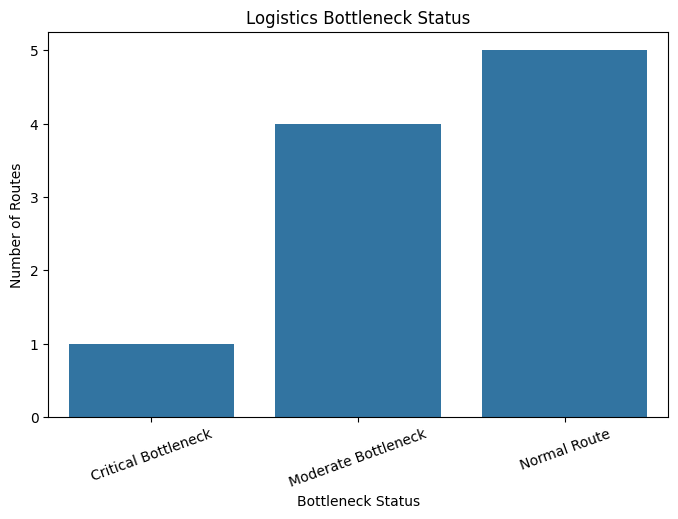

In [59]:
# -------------------------------
# LOGISTICS BOTTLENECK IDENTIFICATION
# -------------------------------

# A bottleneck route has high delay rate, high transport cost, and low route efficiency
delay_threshold = route_summary["Delay_Rate"].quantile(0.75)
cost_threshold = route_summary["Average_Transport_Cost"].quantile(0.75)
efficiency_threshold = route_summary["Average_Route_Efficiency"].quantile(0.25)

def bottleneck_status(row):
    if (
        row["Delay_Rate"] >= delay_threshold
        and row["Average_Transport_Cost"] >= cost_threshold
        and row["Average_Route_Efficiency"] <= efficiency_threshold
    ):
        return "Critical Bottleneck"
    elif (
        row["Delay_Rate"] >= delay_threshold
        or row["Average_Transport_Cost"] >= cost_threshold
    ):
        return "Moderate Bottleneck"
    else:
        return "Normal Route"

route_summary["Bottleneck_Status"] = route_summary.apply(bottleneck_status, axis=1)

bottleneck_summary = route_summary.groupby("Bottleneck_Status").agg(
    Number_of_Routes=("Region", "count"),
    Average_Delay_Rate=("Delay_Rate", "mean"),
    Average_Transport_Cost=("Average_Transport_Cost", "mean"),
    Average_Route_Efficiency=("Average_Route_Efficiency", "mean")
).reset_index()

display(bottleneck_summary)

critical_bottlenecks = route_summary[route_summary["Bottleneck_Status"] != "Normal Route"].sort_values(
    by=["Delay_Rate", "Average_Transport_Cost"],
    ascending=False
)

display(critical_bottlenecks.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=bottleneck_summary, x="Bottleneck_Status", y="Number_of_Routes")
plt.title("Logistics Bottleneck Status")
plt.xlabel("Bottleneck Status")
plt.ylabel("Number of Routes")
plt.xticks(rotation=20)
plt.show()

,Network_Risk_Level,Number_of_Routes,Average_Risk_Score,Average_Delay_Rate,Average_Transport_Cost,Average_Lead_Time_Days
0,High Risk,3,0.540802,0.279398,5664.888869,4.821595
1,Low Risk,4,0.310601,0.164483,1544.723285,2.711589
2,Medium Risk,3,0.457599,0.207194,4176.115483,4.584971


,Region,Supplier,Shipping_Mode,Average_Distance,Average_Transport_Cost,Average_Lead_Time_Days,Delay_Rate,Average_Route_Efficiency,Risk_Score,Network_Risk_Level,Bottleneck_Status
7,West,Warehouse_W,Same Day,1157.579329,7651.495101,4.750786,0.237211,1.318604,0.589624,High Risk,Moderate Bottleneck
8,West,Warehouse_W,Second Class,1105.825464,5555.268874,5.563641,0.294594,2.178982,0.562358,High Risk,Critical Bottleneck
5,South,Warehouse_S,Second Class,751.864557,3787.902632,4.150358,0.306388,2.973079,0.470422,High Risk,Moderate Bottleneck
9,West,Warehouse_W,Standard Class,975.163679,3852.749077,5.469068,0.194421,4.290253,0.465479,Medium Risk,Normal Route
6,South,Warehouse_S,Standard Class,743.128028,3115.802829,4.626547,0.314669,5.751687,0.464542,Medium Risk,Moderate Bottleneck
4,South,Warehouse_S,Same Day,910.176076,5559.794543,3.659299,0.112493,1.643313,0.442777,Medium Risk,Moderate Bottleneck
1,Central,Warehouse_C,Standard Class,450.156131,1911.103938,3.469094,0.246355,14.983738,0.374354,Low Risk,Normal Route
0,Central,Warehouse_C,Second Class,485.179506,2421.383594,3.078551,0.195692,5.724863,0.362868,Low Risk,Normal Route
2,East,Warehouse_E,Second Class,229.189106,1105.311998,1.986359,0.112689,9.776488,0.257822,Low Risk,Normal Route
3,East,Warehouse_E,Standard Class,193.520370,741.093608,2.312354,0.103198,39.279436,0.247360,Low Risk,Normal Route


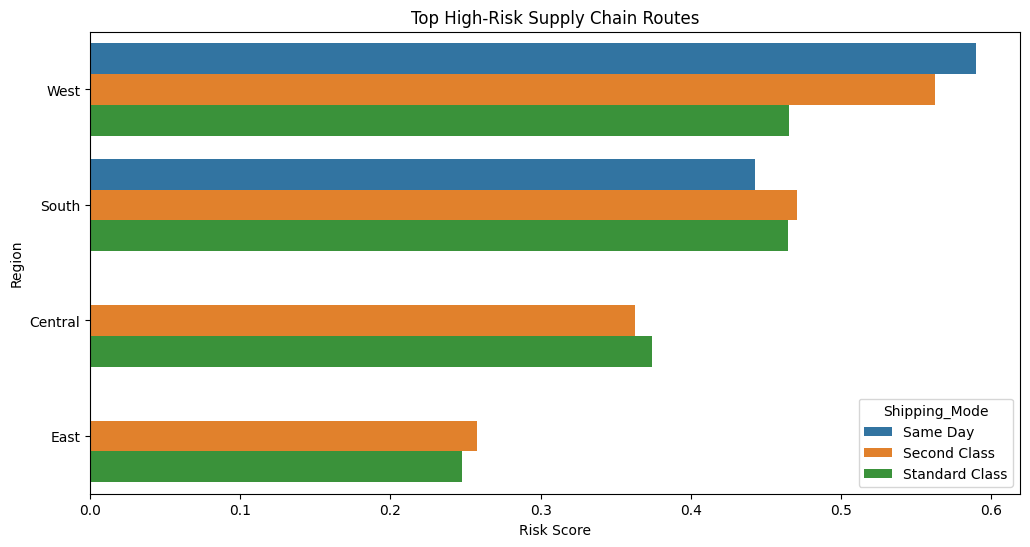

In [60]:
# -------------------------------
# SUPPLY CHAIN NETWORK RISK ANALYSIS
# -------------------------------

# Risk score combines delay, cost, traffic, fuel, and lead time
route_summary["Risk_Score"] = (
    route_summary["Delay_Rate"] * 0.30
    + (route_summary["Average_Transport_Cost"] / route_summary["Average_Transport_Cost"].max()) * 0.25
    + route_summary["Average_Traffic_Index"] * 0.20
    + (route_summary["Average_Lead_Time_Days"] / route_summary["Average_Lead_Time_Days"].max()) * 0.15
    + (route_summary["Average_Fuel_Price"] / route_summary["Average_Fuel_Price"].max()) * 0.10
)

def network_risk_level(value):
    if value >= route_summary["Risk_Score"].quantile(0.75):
        return "High Risk"
    elif value >= route_summary["Risk_Score"].quantile(0.40):
        return "Medium Risk"
    else:
        return "Low Risk"

route_summary["Network_Risk_Level"] = route_summary["Risk_Score"].apply(network_risk_level)

risk_summary = route_summary.groupby("Network_Risk_Level").agg(
    Number_of_Routes=("Region", "count"),
    Average_Risk_Score=("Risk_Score", "mean"),
    Average_Delay_Rate=("Delay_Rate", "mean"),
    Average_Transport_Cost=("Average_Transport_Cost", "mean"),
    Average_Lead_Time_Days=("Average_Lead_Time_Days", "mean")
).reset_index()

display(risk_summary)

high_risk_network = route_summary.sort_values(by="Risk_Score", ascending=False).head(10)

display(high_risk_network[[
    "Region", "Supplier", "Shipping_Mode",
    "Average_Distance", "Average_Transport_Cost",
    "Average_Lead_Time_Days", "Delay_Rate",
    "Average_Route_Efficiency", "Risk_Score",
    "Network_Risk_Level", "Bottleneck_Status"
]])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=high_risk_network,
    x="Risk_Score",
    y="Region",
    hue="Shipping_Mode"
)
plt.title("Top High-Risk Supply Chain Routes")
plt.xlabel("Risk Score")
plt.ylabel("Region")
plt.show()

In [61]:
# -------------------------------
# SAVE SUPPLIER & TRANSPORTATION OUTPUTS FOR POWER BI
# -------------------------------

supplier_summary.to_csv("powerbi_supplier_ranking.csv", index=False)
route_summary.to_csv("powerbi_transport_route_summary.csv", index=False)
fuel_delay_trend.to_csv("powerbi_fuel_delay_trend.csv", index=False)
bottleneck_summary.to_csv("powerbi_bottleneck_summary.csv", index=False)
critical_bottlenecks.to_csv("powerbi_critical_bottlenecks.csv", index=False)
risk_summary.to_csv("powerbi_supply_chain_risk_summary.csv", index=False)
high_risk_network.to_csv("powerbi_high_risk_supply_chain_routes.csv", index=False)

print("Supplier and transportation analytics outputs saved successfully for Power BI!")

Supplier and transportation analytics outputs saved successfully for Power BI!


### Task 6 Interpretation

The supplier and transportation analytics module was completed using a proxy supply chain network created from the Walmart retail dataset.

Since the original dataset does not contain direct supplier names, real routes, transportation cost, or lead time, warehouses were treated as supplier or distribution partners. Regions were created from store groups, and shipping modes were created from store types. Transportation performance was estimated using distance, fuel price, traffic index, delivery delay, and weekly sales.

The supplier ranking shows that Warehouse_E has the highest reliability score. This supplier has the lowest delay rate, shorter lead time, and the strongest route efficiency. Warehouse_S has the lowest reliability score, mainly because it has a higher delay rate and longer lead time. This means Warehouse_S requires more operational attention.

Transportation cost analysis shows that West and South routes are the most expensive, especially when Same Day or Second Class shipping is used. This is mainly caused by longer average distance and higher delivery pressure. These routes should be reviewed for cost optimization.

Route efficiency analysis shows how much sales value is generated per unit of transportation cost. Routes with higher route efficiency are better for the supply chain because they generate more business value with lower logistics pressure. Routes with low efficiency should be checked for possible cost reduction.

Fuel trend analysis shows that fuel price strongly affects transportation cost. The scatter plot confirms that higher fuel prices are connected with higher average transportation cost. This means fuel price should be included in future logistics planning and budgeting.

The bottleneck analysis identified one critical bottleneck and four moderate bottlenecks. The most critical route is West / Warehouse_W / Second Class because it has high delay rate, high transportation cost, and low route efficiency. This route may reduce delivery performance and increase logistics costs.

The supply chain risk analysis identified three high-risk routes. These are mainly West and South routes with Same Day or Second Class shipping. These routes should be monitored carefully, especially during holiday periods and high-demand weeks.

Overall, this module provides supplier rankings, cost optimization insights, bottleneck identification, and supply chain risk analysis. These results can be used in Power BI to build a Supplier and Transportation Analytics dashboard.

## Final Business Insights

After completing the six analytical modules, the project provides an AI-driven retail supply chain intelligence system.

The analysis shows that retail demand is seasonal and strongly affected by store type, department, holiday periods, and store size. Type A stores generate the highest sales and should receive stronger inventory and logistics support.

The forecasting module shows that Random Forest Regressor performs much better than Linear Regression for weekly sales prediction. This means retail demand has non-linear patterns and should be forecasted with machine learning models. Prophet and ARIMA were also used for monthly forecasting and future inventory planning.

The delivery delay module shows that delay risk increases when traffic pressure, fuel price, holiday periods, distance, and order priority are high. The model can identify high-risk routes and support preventive logistics planning.

The inventory optimization module shows that Category A departments generate most of the sales. These departments should be monitored weekly and supported with enough safety stock. Overstock and understock risks were also identified to improve replenishment decisions.

The supplier and transportation analytics module shows that Warehouse_E is the most reliable supplier/distribution partner, while Warehouse_S and Warehouse_W routes need more attention. West and South routes are more expensive and riskier, especially with Same Day and Second Class shipping.

Overall, the project helps the business improve demand forecasting, inventory planning, delivery risk control, supplier ranking, transportation cost management, and supply chain risk monitoring.

In [62]:
# -------------------------------
# COMBINE POWER BI OUTPUTS INTO FEWER FILES
# -------------------------------

# 1. Main retail dataset
# This file is used for Executive Dashboard, Sales Overview, Store Performance, EDA
powerbi_main_retail_data = df.copy()

powerbi_main_retail_data.to_csv("powerbi_main_retail_data.csv", index=False)


# 2. Forecasting dataset
# Combine actual monthly sales, ARIMA forecast, Prophet forecast, and inventory needs

forecasting_data = inventory_forecast.copy()

forecasting_data = forecasting_data.merge(
    arima_forecast_df,
    on="Date",
    how="left"
)

forecasting_data.to_csv("powerbi_forecasting_data.csv", index=False)


# 3. Logistics dataset
# This includes delivery delay predictions and high-risk route information

powerbi_logistics_data = delay_predictions.copy()

powerbi_logistics_data.to_csv("powerbi_logistics_data.csv", index=False)


# 4. Inventory + Supplier + Transportation dataset
# This combines inventory optimization with supplier and route risk summary

inventory_supplier_data = abc_df.copy()

# Save inventory data separately inside the same final file logic
inventory_supplier_data.to_csv("powerbi_inventory_supplier_data.csv", index=False)

# Route and supplier summaries are still useful, but we save them as optional extra files
supplier_summary.to_csv("optional_powerbi_supplier_summary.csv", index=False)
route_summary.to_csv("optional_powerbi_route_summary.csv", index=False)


print("Combined Power BI files saved successfully!")

combined_files = [
    "powerbi_main_retail_data.csv",
    "powerbi_forecasting_data.csv",
    "powerbi_logistics_data.csv",
    "powerbi_inventory_supplier_data.csv",
    "optional_powerbi_supplier_summary.csv",
    "optional_powerbi_route_summary.csv"
]

for file in combined_files:
    print(file)

Combined Power BI files saved successfully!
powerbi_main_retail_data.csv
powerbi_forecasting_data.csv
powerbi_logistics_data.csv
powerbi_inventory_supplier_data.csv
optional_powerbi_supplier_summary.csv
optional_powerbi_route_summary.csv
